<a href="https://colab.research.google.com/github/ricardoalvarezv-cpu/Memoria-LSTM-SSI/blob/main/Resultados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resultados de inferencia — LSTM Teacher / LSTM Student

Este notebook reúne la evaluación de los modelos entrenados dentro del framework propuesto para aproximar la interacción suelo–estructura.

El notebook se organiza en tres bloques principales:

## Bloque 1 — Validación del modelo Teacher
Se evalúa el modelo `LSTM_Teacher` seleccionado como configuración final durante la etapa metodológica.  
La validación se realiza sobre los **10 eventos de validación** del split comparativo 50/10/4, con el fin de justificar cuantitativa y gráficamente por qué este modelo fue adoptado como referencia.

## Bloque 2 — Validación del modelo Student
Se evalúa el modelo `LSTM_Student` utilizando el mismo criterio de validación, permitiendo analizar su capacidad para aproximar la salida del Teacher.

## Bloque 3 — Comparación final de redes completas
Se comparan las respuestas predichas por Teacher y Student frente a la respuesta real obtenida en OpenSees sobre un conjunto de **4 eventos holdout**, completamente fuera del entrenamiento.

Las métricas reportadas incluyen:
- RMSE
- MAE
- Bias
- Correlación
- Error relativo del peak

# **BLOQUE 0 — Setup Común**

# 1.- Setup, loader, resample y modelos base.

In [ ]:
# ============================================
# RESULTS NOTEBOOK — CELDA 1
# Setup común:
# - imports
# - device
# - paths
# - loader npz
# - resample
# - modelos base Teacher / Student
# ============================================
import os
import glob
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ----------------------------
# Dispositivo
# ----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# ----------------------------
# Paths
# ----------------------------
ROOT = "/content/memoria"

CANDIDATES = [
    "/content/memoria/processed_step_full_v2",
    "/content/memoria/processed_step_full_v2/processed_step_full_v2",
]

PROCESSED_DIR = None
for c in CANDIDATES:
    if os.path.isdir(c) and len(glob.glob(os.path.join(c, "EQ*.npz"))) > 0:
        PROCESSED_DIR = c
        break

if PROCESSED_DIR is None:
    raise FileNotFoundError("No encuentro processed_step_full_v2 con EQ*.npz.")

ALL_FILES = sorted(glob.glob(os.path.join(PROCESSED_DIR, "EQ*.npz")))
print("✅ PROCESSED_DIR:", PROCESSED_DIR)
print("✅ EQ encontrados:", len(ALL_FILES))

RUNS_DIR_RESULTS = os.path.join(ROOT, "runs_colab", "runs_results_models")
os.makedirs(RUNS_DIR_RESULTS, exist_ok=True)
print("✅ RUNS_DIR_RESULTS:", RUNS_DIR_RESULTS)

# ----------------------------
# Variables globales comunes
# ----------------------------
DT_REF = 0.005
X_NAMES_FULL = ["vg", "ag", "d_mid_x", "v_mid_x", "a_mid_x"]
Y_NAMES = ["a_base_x", "Fx", "Mz"]
EPS = 1e-8

# ----------------------------
# Loader NPZ
# ----------------------------
def load_event_npz(path: str):
    z = np.load(path, allow_pickle=True)
    keys = list(z.files)

    if "X_full" not in keys or "Y_full" not in keys:
        raise KeyError(f"Faltan X_full/Y_full en {path}. Keys={keys}")

    X = z["X_full"].astype(np.float32)
    Y = z["Y_full"].astype(np.float32)

    dt = float(np.array(z["dt"]).reshape(())) if "dt" in keys else None
    rid = (
        str(np.array(z["record_id"]).reshape(()))
        if "record_id" in keys
        else os.path.splitext(os.path.basename(path))[0]
    )

    assert X.ndim == 2 and X.shape[1] == 5, (rid, X.shape)
    assert Y.ndim == 2 and Y.shape[1] == 3, (rid, Y.shape)

    if dt is None:
        raise ValueError(f"{rid}: no viene dt en el npz.")

    return rid, X, Y, dt

def record_id_from_path(p):
    return os.path.splitext(os.path.basename(p))[0]

# ----------------------------
# Resampling
# ----------------------------
def _moving_average(x, w):
    if w <= 1:
        return x
    k = np.ones(w, dtype=np.float64) / w
    y = np.empty_like(x, dtype=np.float64)
    for j in range(x.shape[1]):
        y[:, j] = np.convolve(x[:, j], k, mode="same")
    return y.astype(np.float32)

def resample_to_dt_ref(X, Y, dt, dt_ref=DT_REF, smooth_if_downsample=True):
    NT = X.shape[0]
    t = np.arange(NT, dtype=np.float64) * float(dt)
    t_end = t[-1]

    t2 = np.arange(0.0, t_end + 0.5 * dt_ref, float(dt_ref), dtype=np.float64)
    NT2 = t2.size

    if smooth_if_downsample and (dt_ref > dt * 1.01):
        ratio = dt_ref / dt
        w = int(np.ceil(ratio))
        Xs = _moving_average(X, w)
        Ys = _moving_average(Y, w)
    else:
        Xs, Ys = X, Y

    Xr = np.empty((NT2, X.shape[1]), dtype=np.float32)
    Yr = np.empty((NT2, Y.shape[1]), dtype=np.float32)

    for j in range(X.shape[1]):
        Xr[:, j] = np.interp(t2, t, Xs[:, j]).astype(np.float32)
    for j in range(Y.shape[1]):
        Yr[:, j] = np.interp(t2, t, Ys[:, j]).astype(np.float32)

    return Xr, Yr, float(dt_ref)

# ----------------------------
# Modelo Teacher
# ----------------------------
class TeacherLSTM(nn.Module):
    def __init__(self, in_dim=5, hid=256, layers=2, dropout=0.0, out_dim=3):
        super().__init__()
        do = float(dropout) if layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=in_dim,
            hidden_size=hid,
            num_layers=layers,
            batch_first=True,
            dropout=do
        )
        self.head = nn.Linear(hid, out_dim)

    def forward(self, x):
        h, _ = self.lstm(x)
        y = self.head(h)
        return y

# ----------------------------
# Modelo Student
# ----------------------------
class SeqStudent(nn.Module):
    def __init__(self, in_dim, hid=128, layers=2, dropout=0.1, out_dim=2):
        super().__init__()
        do = float(dropout) if layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=in_dim,
            hidden_size=hid,
            num_layers=layers,
            batch_first=True,
            dropout=do
        )
        self.head = nn.Linear(hid, out_dim)

    def forward(self, x):
        h, _ = self.lstm(x)
        y = self.head(h)
        return y

print("✅ Setup común listo.")

DEVICE: cuda
GPU: NVIDIA GeForce RTX 4060
✅ PROCESSED_DIR: /content/memoria/processed_step_full_v2
✅ EQ encontrados: 84
✅ RUNS_DIR_RESULTS: /content/memoria/runs_colab/runs_results_models
✅ Setup común listo.


# 2.- Helpers comunes de métricas, ventana activa y plots y escalamiento.

In [ ]:
# ============================================
# RESULTS NOTEBOOK — CELDA 2
# Helpers comunes:
# - ventana activa
# - métricas
# - plots
# - helpers de arquitectura / escalamiento
# ============================================
import numpy as np

def active_strict_indices(y_true, dt, warmup_s=1.0, tail_margin_s=0.5):
    a = np.asarray(y_true[:, 0], dtype=np.float64)
    peak = np.max(np.abs(a)) + 1e-12

    thr_on = 0.05 * peak
    idx_on = np.where(np.abs(a) >= thr_on)[0]
    onset = int(idx_on[0]) if len(idx_on) else 0

    thr_tail = 0.02 * peak
    idx_tail = np.where(np.abs(a) >= thr_tail)[0]
    last = int(idx_tail[-1]) if len(idx_tail) else (len(a) - 1)

    warm = int(round(warmup_s / float(dt)))
    tailm = int(round(tail_margin_s / float(dt)))

    i0 = min(len(a) - 1, max(0, onset + warm))
    i1 = max(i0 + 1, min(len(a), last - tailm + 1))
    return i0, i1

def regression_metrics_block(y_true, y_pred, i0, i1):
    yt = np.asarray(y_true[i0:i1], dtype=np.float64)
    yp = np.asarray(y_pred[i0:i1], dtype=np.float64)

    rows = []
    for ch, name in enumerate(Y_NAMES):
        t = yt[:, ch]
        p = yp[:, ch]

        rmse = float(np.sqrt(np.mean((p - t) ** 2)))
        mae = float(np.mean(np.abs(p - t)))
        bias = float(np.mean(p - t))
        corr = float(np.corrcoef(t, p)[0, 1]) if (np.std(t) > 0 and np.std(p) > 0) else np.nan

        peak_t = float(np.max(np.abs(t)))
        peak_p = float(np.max(np.abs(p)))
        peak_err_rel = float(np.abs(peak_p - peak_t) / (peak_t + 1e-12))

        rows.append({
            "target": name,
            "RMSE": rmse,
            "MAE": mae,
            "Bias": bias,
            "Corr": corr,
            "PeakTrueAbs": peak_t,
            "PeakPredAbs": peak_p,
            "PeakErrRel": peak_err_rel
        })
    return rows

def _get_metrics_dict(out):
    md = {}
    for row in out["mets"]:
        md[row["target"]] = row
    return md

def _plot_one(pdf, t, y_true, y_pred, title, ylab, figsize=(12, 4), dpi=180):
    fig = plt.figure(figsize=figsize)
    plt.plot(t, y_true, label="true")
    plt.plot(t, y_pred, label="pred")
    plt.grid(True, alpha=0.3)
    plt.xlabel("t [s]")
    plt.ylabel(ylab)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    pdf.savefig(fig, dpi=dpi)
    plt.close(fig)

def _infer_arch_from_sd(sd: dict):
    wih0 = sd["lstm.weight_ih_l0"]
    whh0 = sd["lstm.weight_hh_l0"]
    in_dim = int(wih0.shape[1])
    hid = int(whh0.shape[1])
    layers = 0
    while f"lstm.weight_ih_l{layers}" in sd:
        layers += 1
    return in_dim, hid, layers

def _scalerX_from_cfg(cfg: dict):
    xm = np.array(cfg.get("scaler_xm", None), dtype=np.float32)
    xp99 = np.array(cfg.get("scaler_xp99", None), dtype=np.float32)
    assert xm is not None and xp99 is not None and xm.size > 0 and xp99.size > 0, \
        "El checkpoint no trae scaler_xm / scaler_xp99."
    eps = float(cfg.get("scaler_eps", 1e-8))
    clip_x = float(cfg.get("scaler_clip_x", 10.0))
    return {
        "xm": xm,
        "xp99": xp99,
        "eps": eps,
        "clip_x": clip_x
    }

def _normalize_X_only(Xr, scalerX):
    Xr = np.asarray(Xr, np.float32)
    Xn = (Xr - scalerX["xm"]) / (scalerX["xp99"] + scalerX["eps"])
    Xn = np.clip(Xn, -float(scalerX["clip_x"]), float(scalerX["clip_x"]))
    return np.nan_to_num(Xn.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

print("✅ Helpers comunes listos.")

✅ Helpers comunes listos.


In [ ]:
# ============================================
# BLOQUE 0 — UTILIDADES COMUNES
# Teacher/Student | Teacher-space + normalización física compartida
# - evita dependencias ocultas entre bloques
# ============================================
# Esta celda carga SOLO los scalers físicos/globales desde el checkpoint Teacher,
# para que Student y la comparación final puedan normalizar/denormalizar en teacher-space
# sin depender del BLOQUE 1.

PT_TEACHER_SPACE = "/content/memoria/runs_colab/runs_notebook_B_teacher/TEACHER_A_WINDOWS.pt"
assert os.path.exists(PT_TEACHER_SPACE), f"No existe checkpoint Teacher-space: {PT_TEACHER_SPACE}"

_ck_teacher_space = torch.load(PT_TEACHER_SPACE, map_location="cpu", weights_only=False)
_cfg_teacher_space = _ck_teacher_space.get("cfg", {})

required_teacher_keys = ["XM", "YM", "X_P99ABS", "Y_P99ABS"]
missing_teacher_keys = [k for k in required_teacher_keys if k not in _cfg_teacher_space]
assert len(missing_teacher_keys) == 0, (
    f"El checkpoint Teacher no contiene las claves requeridas para teacher-space: {missing_teacher_keys}"
)

# scalers teacher-space globales
XM = np.asarray(_cfg_teacher_space["XM"], dtype=np.float32)
YM = np.asarray(_cfg_teacher_space["YM"], dtype=np.float32)
X_P99ABS = np.asarray(_cfg_teacher_space["X_P99ABS"], dtype=np.float32)
Y_P99ABS = np.asarray(_cfg_teacher_space["Y_P99ABS"], dtype=np.float32)

# clips globales
CLIP_X = float(_cfg_teacher_space.get("clip_x", 10.0))
CLIP_Y = float(_cfg_teacher_space.get("clip_y", 10.0))

def normalize_phys_to_teacher(Y_phys):
    Y_phys = np.asarray(Y_phys, np.float32)
    Yn = (Y_phys - YM) / (Y_P99ABS + EPS)
    Yn = np.clip(Yn, -CLIP_Y, CLIP_Y)
    return np.nan_to_num(Yn.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

def denormalize_phys_from_teacher(Y_norm):
    Y_norm = np.asarray(Y_norm, np.float32)
    Yp = (Y_norm * (Y_P99ABS + EPS)) + YM
    return np.nan_to_num(Yp.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

print("✅ Teacher-space global cargado desde:", os.path.basename(PT_TEACHER_SPACE))
print("✅ XM shape:", XM.shape)
print("✅ YM shape:", YM.shape)
print("✅ X_P99ABS shape:", X_P99ABS.shape)
print("✅ Y_P99ABS shape:", Y_P99ABS.shape)
print("✅ CLIP_X:", CLIP_X, "| CLIP_Y:", CLIP_Y)

✅ Teacher-space global cargado desde: TEACHER_A_WINDOWS.pt
✅ XM shape: (1, 5)
✅ YM shape: (1, 3)
✅ X_P99ABS shape: (1, 5)
✅ Y_P99ABS shape: (1, 3)
✅ CLIP_X: 10.0 | CLIP_Y: 10.0


In [ ]:
# ============================================
# BLOQUE 0 — PARÁMETROS GLOBALES DE INFERENCIA
# ============================================
DT_REF = 0.005
T_BACK_S = 5.12
T_BACK = int(round(T_BACK_S / DT_REF))

print("✅ DT_REF global inferencia:", DT_REF)
print("✅ T_BACK global inferencia:", T_BACK)

✅ DT_REF global inferencia: 0.005
✅ T_BACK global inferencia: 1024


# **BLOQUE 1 — Validación del modelo Teacher**

# 3.- Cargar Checkpoint Teacher seleccionado.

In [ ]:
# ============================================
# BLOQUE 1 — CELDA 3
# Teacher | Carga checkpoint del modelo elegido
# ============================================
PT_TEACHER = "/content/memoria/runs_colab/runs_notebook_B_teacher/TEACHER_A_WINDOWS.pt"
assert os.path.exists(PT_TEACHER), f"No existe checkpoint Teacher: {PT_TEACHER}"

ckpt_teacher = torch.load(PT_TEACHER, map_location="cpu", weights_only=False)
cfg_teacher = ckpt_teacher["cfg"]

print("✅ Checkpoint Teacher cargado")
print("✅ cfg_teacher keys:", list(cfg_teacher.keys()))

model_teacher = TeacherLSTM(
    in_dim=5,
    hid=cfg_teacher["hid"],
    layers=cfg_teacher["layers"],
    dropout=cfg_teacher["dropout"],
    out_dim=3
).to(DEVICE)

model_teacher.load_state_dict(ckpt_teacher["state_dict"], strict=True)
model_teacher.eval()

print("✅ Modelo Teacher reconstruido y cargado")

✅ Checkpoint Teacher cargado
✅ cfg_teacher keys: ['tag', 'hid', 'layers', 'dropout', 'lr', 'epochs_ran', 'train_mode', 'best_val', 'XM', 'YM', 'X_P99ABS', 'Y_P99ABS']
✅ Modelo Teacher reconstruido y cargado


# 4.- Reconstruir split comparativo 64/16/4 y elegir validación

In [ ]:
# ============================================
# BLOQUE 1 — CELDA 4
# Teacher | Split oficial para Resultados
# - VAL teacher = misma validación usada en Teacher
# - TEST final = 4 OOD oficiales
# ============================================
import os
import numpy as np

def record_id_from_path(p):
    return os.path.splitext(os.path.basename(p))[0]

ALL_IDS = sorted([record_id_from_path(p) for p in ALL_FILES])

# --------------------------------------------------
# HOLDOUTS OFICIALES
# --------------------------------------------------
OOD_RIDS = ["EQ007", "EQ019", "EQ052", "EQ081"]

# --------------------------------------------------
# VALIDACIÓN REAL USADA EN TEACHER
# --------------------------------------------------
VAL_IDS_CMP = [
    'EQ004', 'EQ012', 'EQ014', 'EQ021',
    'EQ022', 'EQ027', 'EQ028', 'EQ030',
    'EQ037', 'EQ045', 'EQ050', 'EQ068',
    'EQ070', 'EQ073', 'EQ075', 'EQ083'
]

# --------------------------------------------------
# TRAIN de referencia = todo excepto VAL y OOD
# --------------------------------------------------
TRAIN_IDS_CMP = sorted([
    rid for rid in ALL_IDS
    if rid not in set(VAL_IDS_CMP) and rid not in set(OOD_RIDS)
])

# --------------------------------------------------
# TEST comparativo/final = OOD oficiales
# --------------------------------------------------
TEST_IDS_CMP = list(OOD_RIDS)

val_files_teacher = [
    p for p in ALL_FILES
    if record_id_from_path(p) in VAL_IDS_CMP
]

test_files_cmp = [
    p for p in ALL_FILES
    if record_id_from_path(p) in TEST_IDS_CMP
]

print("=== SPLIT USADO EN RESULTADOS ===")
print("TRAIN_IDS_CMP:", TRAIN_IDS_CMP)
print("VAL_IDS_CMP:  ", VAL_IDS_CMP)
print("TEST_IDS_CMP: ", TEST_IDS_CMP)

assert len(VAL_IDS_CMP) == 16, f"VAL teacher debe tener 16 eventos, pero tiene {len(VAL_IDS_CMP)}"
assert len(TEST_IDS_CMP) == 4, f"TEST debe tener 4 eventos, pero tiene {len(TEST_IDS_CMP)}"
assert len(val_files_teacher) == 16, f"val_files_teacher debe tener 16 eventos, pero tiene {len(val_files_teacher)}"
assert len(test_files_cmp) == 4, f"test_files_cmp debe tener 4 eventos, pero tiene {len(test_files_cmp)}"

print("\n✅ val_files_teacher:", [record_id_from_path(p) for p in val_files_teacher])
print("✅ test_files_cmp:", [record_id_from_path(p) for p in test_files_cmp])

=== SPLIT USADO EN RESULTADOS ===
TRAIN_IDS_CMP: ['EQ001', 'EQ002', 'EQ003', 'EQ005', 'EQ006', 'EQ008', 'EQ009', 'EQ010', 'EQ011', 'EQ013', 'EQ015', 'EQ016', 'EQ018', 'EQ023', 'EQ024', 'EQ025', 'EQ026', 'EQ029', 'EQ031', 'EQ032', 'EQ033', 'EQ034', 'EQ035', 'EQ036', 'EQ038', 'EQ039', 'EQ040', 'EQ041', 'EQ042', 'EQ043', 'EQ044', 'EQ046', 'EQ047', 'EQ048', 'EQ049', 'EQ051', 'EQ053', 'EQ054', 'EQ055', 'EQ056', 'EQ057', 'EQ058', 'EQ059', 'EQ060', 'EQ061', 'EQ062', 'EQ063', 'EQ064', 'EQ065', 'EQ066', 'EQ067', 'EQ069', 'EQ071', 'EQ072', 'EQ074', 'EQ076', 'EQ077', 'EQ078', 'EQ079', 'EQ080', 'EQ082', 'EQ084', 'EQ085', 'EQ086']
VAL_IDS_CMP:   ['EQ004', 'EQ012', 'EQ014', 'EQ021', 'EQ022', 'EQ027', 'EQ028', 'EQ030', 'EQ037', 'EQ045', 'EQ050', 'EQ068', 'EQ070', 'EQ073', 'EQ075', 'EQ083']
TEST_IDS_CMP:  ['EQ007', 'EQ019', 'EQ052', 'EQ081']

✅ val_files_teacher: ['EQ004', 'EQ012', 'EQ014', 'EQ021', 'EQ022', 'EQ027', 'EQ028', 'EQ030', 'EQ037', 'EQ045', 'EQ050', 'EQ068', 'EQ070', 'EQ073', 'EQ075', 'EQ0

# 5.- Reconstrucción cfg del Teacher y funcion de predicción

In [ ]:
# ============================================
# BLOQUE 1 — CELDA 5
# Teacher | Reconstrucción cfg + predicción física
# - Versión robusta para checkpoints comparativos
# ============================================
import numpy as np
import torch

# --------------------------------------------------
# Parámetros reconstruidos desde el entrenamiento
# --------------------------------------------------
# El checkpoint TEACHER_A_WINDOWS.pt no necesariamente guarda:
#   dt_ref
#   T_back
# Por eso aquí se reconstruyen manualmente usando
# la configuración del notebook de entrenamiento.
# --------------------------------------------------

DT_REF_T   = 0.005
T_BACK_S_T = 5.12
T_BACK_T   = int(round(T_BACK_S_T / DT_REF_T))   # 1024

CLIP_X_T = 10.0
CLIP_Y_T = 10.0

print("✅ DT_REF_T:", DT_REF_T)
print("✅ T_BACK_S_T:", T_BACK_S_T)
print("✅ T_BACK_T:", T_BACK_T)

# --------------------------------------------------
# Scalers guardados en checkpoint
# --------------------------------------------------
if "XM" not in cfg_teacher:
    raise KeyError("cfg_teacher no contiene 'XM'")
if "YM" not in cfg_teacher:
    raise KeyError("cfg_teacher no contiene 'YM'")
if "X_P99ABS" not in cfg_teacher:
    raise KeyError("cfg_teacher no contiene 'X_P99ABS'")
if "Y_P99ABS" not in cfg_teacher:
    raise KeyError("cfg_teacher no contiene 'Y_P99ABS'")

XM_T = np.asarray(cfg_teacher["XM"], dtype=np.float32)
YM_T = np.asarray(cfg_teacher["YM"], dtype=np.float32)
X_P99ABS_T = np.asarray(cfg_teacher["X_P99ABS"], dtype=np.float32)
Y_P99ABS_T = np.asarray(cfg_teacher["Y_P99ABS"], dtype=np.float32)

print("✅ XM_T shape:", XM_T.shape)
print("✅ YM_T shape:", YM_T.shape)
print("✅ X_P99ABS_T shape:", X_P99ABS_T.shape)
print("✅ Y_P99ABS_T shape:", Y_P99ABS_T.shape)

# --------------------------------------------------
# Predicción Teacher sobre evento completo
# --------------------------------------------------
@torch.no_grad()
def predict_teacher_validation_event(path, model, stride_eval=16):
    rid, X, Y, dt = load_event_npz(path)

    # ----------------------------
    # Resample a dt_ref de entrenamiento
    # ----------------------------
    Xr, Yr, dt2 = resample_to_dt_ref(X, Y, dt, dt_ref=DT_REF_T)

    # ----------------------------
    # Normalización
    # ----------------------------
    Xn = (Xr - XM_T) / (X_P99ABS_T + EPS)
    Xn = np.clip(Xn, -CLIP_X_T, CLIP_X_T)
    Xn = np.nan_to_num(Xn.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    NT = Xn.shape[0]

    ypred_n = np.zeros((NT, 3), dtype=np.float32)
    cnt     = np.zeros((NT, 1), dtype=np.float32)

    # ----------------------------
    # Inference con overlap-add
    # ----------------------------
    for t0 in range(0, NT - T_BACK_T + 1, stride_eval):
        xb = torch.from_numpy(Xn[t0:t0 + T_BACK_T][None, :, :]).to(DEVICE)
        xb = torch.nan_to_num(xb, nan=0.0, posinf=0.0, neginf=0.0)

        yh = model(xb).detach().cpu().numpy()[0]   # (T,3)

        ypred_n[t0:t0 + T_BACK_T] += yh
        cnt[t0:t0 + T_BACK_T] += 1.0

    # asegurar cobertura final
    if cnt[-1, 0] == 0 and NT >= T_BACK_T:
        t0 = NT - T_BACK_T

        xb = torch.from_numpy(Xn[t0:t0 + T_BACK_T][None, :, :]).to(DEVICE)
        xb = torch.nan_to_num(xb, nan=0.0, posinf=0.0, neginf=0.0)

        yh = model(xb).detach().cpu().numpy()[0]

        ypred_n[t0:t0 + T_BACK_T] += yh
        cnt[t0:t0 + T_BACK_T] += 1.0

    ypred_n /= np.maximum(cnt, 1.0)

    # ----------------------------
    # Desnormalización
    # ----------------------------
    Yp = (ypred_n * (Y_P99ABS_T + EPS)) + YM_T

    Yp = np.nan_to_num(Yp.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    Yr = np.nan_to_num(Yr.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    return rid, Yr, Yp, dt2

print("✅ Función predict_teacher_validation_event lista.")

✅ DT_REF_T: 0.005
✅ T_BACK_S_T: 5.12
✅ T_BACK_T: 1024
✅ XM_T shape: (1, 5)
✅ YM_T shape: (1, 3)
✅ X_P99ABS_T shape: (1, 5)
✅ Y_P99ABS_T shape: (1, 3)
✅ Función predict_teacher_validation_event lista.


# 6.- Calcular métricas de validacion Teacher

In [ ]:
# ============================================
# BLOQUE 1 — CELDA 6
# Teacher | Métricas sobre los 10 eventos de validación
# ============================================
STRIDE_EVAL_TEACHER = 16
RESULTS_VAL_TEACHER = {}
SCATTER_ROWS_TEACHER_VAL = []

for p in val_files_teacher:
    t0_eval = time.perf_counter()

    rid, Yr, Yp, dt2 = predict_teacher_validation_event(
        p,
        model_teacher,
        stride_eval=STRIDE_EVAL_TEACHER
    )

    eval_time = time.perf_counter() - t0_eval

    i0, i1 = active_strict_indices(Yr, dt2, warmup_s=1.0, tail_margin_s=0.5)
    for ch, target_name in enumerate(["a_base_x", "Fx", "Mz"]):
        yt = Yr[i0:i1, ch].reshape(-1)
        yp = Yp[i0:i1, ch].reshape(-1)
        err = yp - yt

        for k in range(len(yt)):
            SCATTER_ROWS_TEACHER_VAL.append({
                "event": rid,
                "target": target_name,
                "split": "val_teacher",
                "y_true": float(yt[k]),
                "y_pred": float(yp[k]),
                "error": float(err[k]),
            })
    mets = regression_metrics_block(Yr, Yp, i0, i1)

    RESULTS_VAL_TEACHER[rid] = {
        "Yr": Yr,
        "Yp": Yp,
        "dt_ref": dt2,
        "i0": i0,
        "i1": i1,
        "mets": mets,
        "eval_time_s": eval_time
    }

    print(f"\n=== TEACHER VALIDATION | {rid} | ACTIVE [{i0}:{i1}] ===")
    for row in mets:
        print(
            f"  {row['target']:8s} | RMSE={row['RMSE']:.6g} | "
            f"MAE={row['MAE']:.6g} | Bias={row['Bias']:+.3g} | "
            f"Corr={row['Corr']:+.3f} | PeakErrRel={row['PeakErrRel']:.3f}"
        )

print("\n✅ RESULTS_VAL_TEACHER creado.")
df_teacher_val_scatter = pd.DataFrame(SCATTER_ROWS_TEACHER_VAL)

CSV_TEACHER_VAL_SCATTER = os.path.join(
    RUNS_DIR_RESULTS,
    "TEACHER_VAL_SCATTER_DATA.csv"
)
df_teacher_val_scatter.to_csv(CSV_TEACHER_VAL_SCATTER, index=False)

print("✅ Scatter/error data Teacher validación guardado en:", CSV_TEACHER_VAL_SCATTER)


=== TEACHER VALIDATION | EQ004 | ACTIVE [378:5892] ===
  a_base_x | RMSE=0.154258 | MAE=0.100287 | Bias=+0.0553 | Corr=+0.897 | PeakErrRel=0.090
  Fx       | RMSE=20.8062 | MAE=14.746 | Bias=+11.7 | Corr=+0.925 | PeakErrRel=0.173
  Mz       | RMSE=637.2 | MAE=550.749 | Bias=-539 | Corr=+0.933 | PeakErrRel=0.054

=== TEACHER VALIDATION | EQ012 | ACTIVE [625:7218] ===
  a_base_x | RMSE=0.432418 | MAE=0.243384 | Bias=+0.0536 | Corr=+0.986 | PeakErrRel=0.158
  Fx       | RMSE=47.1677 | MAE=30.9379 | Bias=+12.2 | Corr=+0.992 | PeakErrRel=0.047
  Mz       | RMSE=1195.35 | MAE=911.713 | Bias=-576 | Corr=+0.977 | PeakErrRel=0.055

=== TEACHER VALIDATION | EQ014 | ACTIVE [350:7898] ===
  a_base_x | RMSE=0.146584 | MAE=0.100995 | Bias=+0.0614 | Corr=+0.968 | PeakErrRel=0.235
  Fx       | RMSE=21.9934 | MAE=16.0869 | Bias=+10.9 | Corr=+0.979 | PeakErrRel=0.148
  Mz       | RMSE=816.709 | MAE=644.451 | Bias=-525 | Corr=+0.973 | PeakErrRel=0.028

=== TEACHER VALIDATION | EQ021 | ACTIVE [1111:7897]

# 7.- Construir tabla final de validación Teacher

In [ ]:
# ============================================
# BLOQUE 1 — CELDA 7
# Teacher | Tabla final de métricas de validación
# ============================================
ROWS_VAL_TEACHER = []

for rid, out in RESULTS_VAL_TEACHER.items():
    i0, i1 = out["i0"], out["i1"]
    active_len = int(i1 - i0)
    eval_time = out["eval_time_s"]

    for row in out["mets"]:
        ROWS_VAL_TEACHER.append({
            "Model": cfg_teacher.get("tag", "TEACHER_A_WINDOWS"),
            "Event": rid,
            "Split": "Validation",
            "dt_ref": out["dt_ref"],
            "active_len": active_len,
            "EvalTime_s": eval_time,
            **row
        })

df_val_metrics_teacher = pd.DataFrame(ROWS_VAL_TEACHER)

print("=== TABLA COMPLETA VALIDACIÓN TEACHER ===")
display(df_val_metrics_teacher)

print("\n=== PROMEDIO POR TARGET (VALIDACIÓN TEACHER) ===")
display(
    df_val_metrics_teacher.groupby("target")[
        ["RMSE", "MAE", "Bias", "Corr", "PeakErrRel", "EvalTime_s"]
    ].mean()
)

CSV_VAL_TEACHER = os.path.join(
    RUNS_DIR_RESULTS,
    f"{cfg_teacher.get('tag', 'TEACHER_A_WINDOWS')}_VALIDATION_METRICS.csv"
)
df_val_metrics_teacher.to_csv(CSV_VAL_TEACHER, index=False)

print("\n✅ CSV guardado:", CSV_VAL_TEACHER)

=== TABLA COMPLETA VALIDACIÓN TEACHER ===


,Model,Event,Split,dt_ref,active_len,EvalTime_s,target,RMSE,MAE,Bias,Corr,PeakTrueAbs,PeakPredAbs,PeakErrRel
0,TEACHER_A_WINDOWS,EQ004,Validation,0.005,5514,16.505597,a_base_x,0.154258,0.100287,0.055293,0.897298,1.819780,1.655535,0.090255
1,TEACHER_A_WINDOWS,EQ004,Validation,0.005,5514,16.505597,Fx,20.806225,14.745976,11.673877,0.924747,241.255997,199.571152,0.172783
2,TEACHER_A_WINDOWS,EQ004,Validation,0.005,5514,16.505597,Mz,637.200227,550.748637,-538.597224,0.933083,3480.469971,3667.385986,0.053704
3,TEACHER_A_WINDOWS,EQ012,Validation,0.005,6593,24.594826,a_base_x,0.432418,0.243384,0.053637,0.985778,15.846300,13.347035,0.157719
4,TEACHER_A_WINDOWS,EQ012,Validation,0.005,6593,24.594826,Fx,47.167672,30.937899,12.154871,0.992110,2391.320068,2278.528076,0.047167
5,TEACHER_A_WINDOWS,EQ012,Validation,0.005,6593,24.594826,Mz,1195.351547,911.713383,-575.590997,0.977230,24616.599609,23263.601562,0.054963
6,TEACHER_A_WINDOWS,EQ014,Validation,0.005,7548,22.682054,a_base_x,0.146584,0.100995,0.061368,0.968092,2.677840,2.047839,0.235265
7,TEACHER_A_WINDOWS,EQ014,Validation,0.005,7548,22.682054,Fx,21.993430,16.086904,10.904567,0.979490,404.907013,345.139069,0.147609
8,TEACHER_A_WINDOWS,EQ014,Validation,0.005,7548,22.682054,Mz,816.708709,644.450670,-524.547386,0.972523,6994.950195,7188.253418,0.027635
9,TEACHER_A_WINDOWS,EQ021,Validation,0.005,6786,23.465531,a_base_x,0.515979,0.274437,0.063647,0.980632,10.864300,10.021138,0.077608



=== PROMEDIO POR TARGET (VALIDACIÓN TEACHER) ===


,RMSE,MAE,Bias,Corr,PeakErrRel,EvalTime_s
target,,,,,,
Fx,41.087289,26.379046,11.297893,0.909088,0.255171,61.443971
Mz,1343.336494,972.764051,-546.077420,0.896368,0.926595,61.443971
a_base_x,0.281302,0.167308,0.063498,0.880650,0.169467,61.443971



✅ CSV guardado: /content/memoria/runs_colab/runs_results_models/TEACHER_A_WINDOWS_VALIDATION_METRICS.csv


# 8.- PDF de plots de validación Teacher

In [ ]:
# ============================================
# BLOQUE 1 — CELDA 8
# Teacher | Plots sobre los 10 eventos de validación
# ============================================
PLOT_GLOBAL = True
PLOT_ACTIVE_ONLY = True
FIGSIZE = (12, 4)
DPI = 180

PDF_VAL_TEACHER = os.path.join(
    RUNS_DIR_RESULTS,
    f"{cfg_teacher.get('tag', 'TEACHER_A_WINDOWS')}_VALIDATION_PLOTS.pdf"
)

with PdfPages(PDF_VAL_TEACHER) as pdf:
    fig = plt.figure(figsize=(12, 3))
    plt.axis("off")
    plt.text(
        0.01, 0.7,
        f"Teacher validation\n"
        f"checkpoint={cfg_teacher.get('tag', 'TEACHER_A_WINDOWS')}\n"
        f"val_ids={VAL_IDS_CMP}\n"
        f"PLOT_ACTIVE_ONLY={PLOT_ACTIVE_ONLY} | PLOT_GLOBAL={PLOT_GLOBAL}",
        fontsize=12
    )
    plt.tight_layout()
    pdf.savefig(fig, dpi=DPI)
    plt.close(fig)

    for rid, out in RESULTS_VAL_TEACHER.items():
        Yr = out["Yr"]
        Yp = out["Yp"]
        i0, i1 = int(out["i0"]), int(out["i1"])
        dt2 = float(out["dt_ref"])

        t_all = np.arange(Yr.shape[0]) * dt2
        sl = slice(i0, i1)
        md = _get_metrics_dict(out)

        if PLOT_ACTIVE_ONLY:
            _plot_one(
                pdf,
                t_all[sl], Yr[sl, 0], Yp[sl, 0],
                title=f"{rid} | a_base_x | VALID ACTIVE [{i0}:{i1}] | RMSE={md['a_base_x']['RMSE']:.4g} | Corr={md['a_base_x']['Corr']:+.3f}",
                ylab="a_base_x",
                figsize=FIGSIZE, dpi=DPI
            )
            _plot_one(
                pdf,
                t_all[sl], Yr[sl, 1], Yp[sl, 1],
                title=f"{rid} | Fx | VALID ACTIVE [{i0}:{i1}] | RMSE={md['Fx']['RMSE']:.4g} | Corr={md['Fx']['Corr']:+.3f}",
                ylab="Fx",
                figsize=FIGSIZE, dpi=DPI
            )
            _plot_one(
                pdf,
                t_all[sl], Yr[sl, 2], Yp[sl, 2],
                title=f"{rid} | Mz | VALID ACTIVE [{i0}:{i1}] | RMSE={md['Mz']['RMSE']:.4g} | Corr={md['Mz']['Corr']:+.3f}",
                ylab="Mz",
                figsize=FIGSIZE, dpi=DPI
            )

        if PLOT_GLOBAL:
            _plot_one(pdf, t_all, Yr[:, 0], Yp[:, 0], title=f"{rid} | a_base_x | VALID GLOBAL", ylab="a_base_x", figsize=FIGSIZE, dpi=DPI)
            _plot_one(pdf, t_all, Yr[:, 1], Yp[:, 1], title=f"{rid} | Fx | VALID GLOBAL",       ylab="Fx",       figsize=FIGSIZE, dpi=DPI)
            _plot_one(pdf, t_all, Yr[:, 2], Yp[:, 2], title=f"{rid} | Mz | VALID GLOBAL",       ylab="Mz",       figsize=FIGSIZE, dpi=DPI)

print("✅ PDF guardado:", PDF_VAL_TEACHER)

✅ PDF guardado: /content/memoria/runs_colab/runs_results_models/TEACHER_A_WINDOWS_VALIDATION_PLOTS.pdf


# **BLOQUE 2 — Validación del modelo Student**

Este bloque replica el mismo flujo aplicado al Teacher:
- carga checkpoint del Student
- reconstrucción del split comparativo
- evaluación sobre los 10 eventos de validación
- exportación de métricas
- generación de plots

# 9.- Cargar  checkpoints Student seleccionados

In [ ]:
# ============================================
# BLOQUE 2 — CELDA 9
# Student | Carga checkpoints finales seleccionados
# - AF congelado real = fold2
# - MZ TRUE-only = BESTCORR
# ============================================
import os
import torch

PT_STUDENT_AF = "/content/memoria/runs_colab/runs_notebook_A_student/STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt"
PT_STUDENT_MZ = "/content/memoria/runs_colab/runs_notebook_A_student/STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE_BESTCORR.pt"

assert os.path.exists(PT_STUDENT_AF), f"No existe checkpoint Student AF: {PT_STUDENT_AF}"
assert os.path.exists(PT_STUDENT_MZ), f"No existe checkpoint Student MZ: {PT_STUDENT_MZ}"

ckpt_student_af = torch.load(PT_STUDENT_AF, map_location="cpu", weights_only=False)
cfg_student_af = ckpt_student_af.get("cfg", {})
sd_student_af = ckpt_student_af["state_dict"]

ckpt_student_mz = torch.load(PT_STUDENT_MZ, map_location="cpu", weights_only=False)
cfg_student_mz = ckpt_student_mz.get("cfg", {})
sd_student_mz = ckpt_student_mz["state_dict"]

# ----------------------------
# AF
# ----------------------------
in_dim_af, hid_af, layers_af = _infer_arch_from_sd(sd_student_af)
drop_af = float(cfg_student_af.get("dropout", 0.1))
T_BACK_AF = int(cfg_student_af.get("T_BACK", cfg_student_af.get("T_BACK_AF", 2048)))
SCALERX_AF = _scalerX_from_cfg(cfg_student_af)

model_student_af = SeqStudent(
    in_dim=in_dim_af,
    hid=hid_af,
    layers=layers_af,
    dropout=drop_af,
    out_dim=2
).to(DEVICE)
model_student_af.load_state_dict(sd_student_af, strict=True)
model_student_af.eval()

# ----------------------------
# MZ
# ----------------------------
in_dim_mz, hid_mz, layers_mz = _infer_arch_from_sd(sd_student_mz)
drop_mz = float(cfg_student_mz.get("dropout", 0.1))
T_BACK_MZ = int(cfg_student_mz.get("T_BACK", cfg_student_mz.get("T_BACK_MZ", 1024)))

model_student_mz = SeqStudent(
    in_dim=in_dim_mz,
    hid=hid_mz,
    layers=layers_mz,
    dropout=drop_mz,
    out_dim=1
).to(DEVICE)
model_student_mz.load_state_dict(sd_student_mz, strict=True)
model_student_mz.eval()

print("✅ Student AF cargado:", os.path.basename(PT_STUDENT_AF))
print("   fold_id =", cfg_student_af.get("fold_id", "NA"))
print("   in_dim  =", in_dim_af, "| hid =", hid_af, "| layers =", layers_af, "| T_BACK_AF =", T_BACK_AF)

print("✅ Student MZ cargado:", os.path.basename(PT_STUDENT_MZ))
print("   in_dim  =", in_dim_mz, "| hid =", hid_mz, "| layers =", layers_mz, "| T_BACK_MZ =", T_BACK_MZ)
print("   cfg_mz  =", cfg_student_mz)

✅ Student AF cargado: STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt
   fold_id = 2
   in_dim  = 2 | hid = 128 | layers = 2 | T_BACK_AF = 2048
✅ Student MZ cargado: STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE_BESTCORR.pt
   in_dim  = 4 | hid = 128 | layers = 2 | T_BACK_MZ = 1024
   cfg_mz  = {'run': 'STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE', 'lr': 0.0003, 'stride': 16, 'inputs': '[vgN,agN,abxTRUE,fxTRUE]', 'target': 'MzTRUE', 'upper_bound': True}


# 10.- Reconstruir eventos de validación Student

In [ ]:
# ============================================
# BLOQUE 2 — CELDA 10
# Student | Reconstrucción de eventos de validación
# - AF final: reconstruido desde fold_id del checkpoint congelado
# - Mz TRUE-only: sin split oficial reproducible en cfg
# ============================================
from sklearn.model_selection import GroupKFold
import numpy as np

# --------------------------------------------------
# Utilidades
# --------------------------------------------------
ALL_FILES_SORTED = sorted(ALL_FILES)
ALL_IDS_SORTED = [record_id_from_path(p) for p in ALL_FILES_SORTED]

# --------------------------------------------------
# A) Validación AF final
# Reconstrucción EXACTA usando:
#   - OOD oficiales fuera
#   - GroupKFold(n_splits=5)
#   - fold_id guardado en cfg_student_af
# --------------------------------------------------
OOD_SET = set(OOD_RIDS)

DEV_FILES_STUDENT = [
    p for p in ALL_FILES_SORTED
    if record_id_from_path(p) not in OOD_SET
]
DEV_RIDS_STUDENT = np.array([record_id_from_path(p) for p in DEV_FILES_STUDENT], dtype=object)

assert len(DEV_FILES_STUDENT) == 80, f"Se esperaban 80 eventos de desarrollo y encontré {len(DEV_FILES_STUDENT)}"

AF_FINAL_FOLD_IDX = int(cfg_student_af["fold_id"])
N_SPLITS_AF = 5

X_dummy = np.zeros((len(DEV_FILES_STUDENT), 1), dtype=np.float32)

gkf = GroupKFold(n_splits=N_SPLITS_AF)

folds_files_student = []
for tr_idx, va_idx in gkf.split(X_dummy, groups=DEV_RIDS_STUDENT):
    tr_files = [DEV_FILES_STUDENT[i] for i in tr_idx]
    va_files = [DEV_FILES_STUDENT[i] for i in va_idx]
    folds_files_student.append((tr_files, va_files))

train_files_student_af = list(folds_files_student[AF_FINAL_FOLD_IDX][0])
val_files_student_af   = list(folds_files_student[AF_FINAL_FOLD_IDX][1])

VAL_IDS_STUDENT_AF = [record_id_from_path(p) for p in val_files_student_af]

# --------------------------------------------------
# B) Validación Mz TRUE-only
# El checkpoint MZ NO guarda train_rids / val_rids.
# Por lo tanto, no reconstruimos aquí una validación "oficial".
# Se deja vacío para evitar reportar una validación incorrecta.
# --------------------------------------------------
VAL_IDS_STUDENT_MZ = []
val_files_student_mz = []

print("=== VALIDACIÓN STUDENT ===")
print("AF final | fold =", AF_FINAL_FOLD_IDX)
print("AF val ids:", VAL_IDS_STUDENT_AF)
print("Mz TRUE-only val ids:", VAL_IDS_STUDENT_MZ)

print("\n✅ n_train_files_student_af =", len(train_files_student_af))
print("✅ n_val_files_student_af   =", len(val_files_student_af))
print("✅ n_val_files_student_mz   =", len(val_files_student_mz))

=== VALIDACIÓN STUDENT ===
AF final | fold = 2
AF val ids: ['EQ003', 'EQ009', 'EQ014', 'EQ022', 'EQ027', 'EQ032', 'EQ037', 'EQ042', 'EQ047', 'EQ053', 'EQ058', 'EQ063', 'EQ068', 'EQ073', 'EQ078', 'EQ084']
Mz TRUE-only val ids: []

✅ n_train_files_student_af = 64
✅ n_val_files_student_af   = 16
✅ n_val_files_student_mz   = 0


# 11.- Funciones de predicción Student para validación

In [ ]:
# ============================================
# BLOQUE 2 — CELDA 11
# Student | Funciones de predicción de validación
# ============================================
@torch.no_grad()
def predict_student_af_full_event(Xr, stride_eval=64):
    Xn_full = _normalize_X_only(Xr, SCALERX_AF)
    Xs = Xn_full[:, [0, 1]].astype(np.float32)   # vg, ag
    NT = int(Xs.shape[0])

    y_sum = np.zeros((NT, 2), np.float32)
    y_cnt = np.zeros((NT, 1), np.float32)

    last0 = max(0, NT - T_BACK_AF)
    t0s = list(range(0, max(1, NT - T_BACK_AF + 1), stride_eval))
    if len(t0s) == 0 or t0s[-1] != last0:
        t0s.append(last0)

    for t0 in t0s:
        win = Xs[t0:t0+T_BACK_AF, :]
        if win.shape[0] < T_BACK_AF:
            pad = np.repeat(win[-1:, :], T_BACK_AF - win.shape[0], axis=0)
            win = np.concatenate([win, pad], axis=0)

        xb = torch.from_numpy(win[None, :, :]).float().to(DEVICE)
        yh = model_student_af(xb).squeeze(0).detach().cpu().numpy().astype(np.float32)

        t1 = min(NT, t0 + T_BACK_AF)
        y_sum[t0:t1, :] += yh[:(t1-t0), :]
        y_cnt[t0:t1, :] += 1.0

    y_cnt[y_cnt == 0] = 1.0
    return np.nan_to_num((y_sum / y_cnt).astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

@torch.no_grad()
def predict_student_af_validation_event(path, stride_eval=64):
    rid, X, Y, dt = load_event_npz(path)
    Xr, Yr, dt2 = resample_to_dt_ref(X, Y, dt, dt_ref=DT_REF)
    Yr = np.nan_to_num(Yr.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    y_af_hat_n = predict_student_af_full_event(Xr, stride_eval=stride_eval)

    Y_af_n_3 = np.zeros((y_af_hat_n.shape[0], 3), dtype=np.float32)
    Y_af_n_3[:, 0] = y_af_hat_n[:, 0]
    Y_af_n_3[:, 1] = y_af_hat_n[:, 1]

    Y_af_phys_3 = denormalize_phys_from_teacher(Y_af_n_3)
    Y_af_phys = Y_af_phys_3[:, :2]

    return rid, Yr, Y_af_phys.astype(np.float32), dt2

@torch.no_grad()
def predict_student_mz_trueonly_event(path, stride_eval=16):
    rid, X, Y, dt = load_event_npz(path)
    Xr, Yr, dt2 = resample_to_dt_ref(X, Y, dt, dt_ref=DT_REF)
    Yr = np.nan_to_num(Yr.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    Xn_full = _normalize_X_only(Xr, SCALERX_AF)
    Yr_n = normalize_phys_to_teacher(Yr)

    X4_true = np.stack([
        Xn_full[:, 0],   # vg_n
        Xn_full[:, 1],   # ag_n
        Yr_n[:, 0],      # abx_true_n
        Yr_n[:, 1],      # fx_true_n
    ], axis=1).astype(np.float32)

    NT = int(X4_true.shape[0])
    y_sum = np.zeros((NT, 1), np.float32)
    y_cnt = np.zeros((NT, 1), np.float32)

    last0 = max(0, NT - T_BACK_MZ)
    t0s = list(range(0, max(1, NT - T_BACK_MZ + 1), stride_eval))
    if len(t0s) == 0 or t0s[-1] != last0:
        t0s.append(last0)

    for t0 in t0s:
        win = X4_true[t0:t0+T_BACK_MZ, :]
        if win.shape[0] < T_BACK_MZ:
            pad = np.repeat(win[-1:, :], T_BACK_MZ - win.shape[0], axis=0)
            win = np.concatenate([win, pad], axis=0)

        xb = torch.from_numpy(win[None, :, :]).float().to(DEVICE)
        yh = model_student_mz(xb).squeeze(0).detach().cpu().numpy().astype(np.float32)

        t1 = min(NT, t0 + T_BACK_MZ)
        y_sum[t0:t1, :] += yh[:(t1-t0), :]
        y_cnt[t0:t1, :] += 1.0

    y_cnt[y_cnt == 0] = 1.0
    mz_hat_n = (y_sum / y_cnt).reshape(-1).astype(np.float32)

    Y_mz_n_3 = np.zeros((NT, 3), dtype=np.float32)
    Y_mz_n_3[:, 2] = mz_hat_n

    Y_mz_phys_3 = denormalize_phys_from_teacher(Y_mz_n_3)
    mz_hat_phys = Y_mz_phys_3[:, 2]

    return rid, Yr, mz_hat_phys.astype(np.float32), dt2

def regression_metrics_block_af_only(y_true, y_pred, i0, i1):
    yt = np.asarray(y_true[i0:i1, :2], dtype=np.float64)
    yp = np.asarray(y_pred[i0:i1, :2], dtype=np.float64)

    names = ["a_base_x", "Fx"]
    rows = []

    for ch, name in enumerate(names):
        t = yt[:, ch]
        p = yp[:, ch]

        rmse = float(np.sqrt(np.mean((p - t) ** 2)))
        mae = float(np.mean(np.abs(p - t)))
        bias = float(np.mean(p - t))
        corr = float(np.corrcoef(t, p)[0, 1]) if (np.std(t) > 0 and np.std(p) > 0) else np.nan

        peak_t = float(np.max(np.abs(t)))
        peak_p = float(np.max(np.abs(p)))
        peak_err_rel = float(np.abs(peak_p - peak_t) / (peak_t + 1e-12))

        rows.append({
            "target": name,
            "RMSE": rmse,
            "MAE": mae,
            "Bias": bias,
            "Corr": corr,
            "PeakTrueAbs": peak_t,
            "PeakPredAbs": peak_p,
            "PeakErrRel": peak_err_rel
        })
    return rows

def regression_metrics_single_target(y_true, y_pred, i0, i1, target_name="Mz"):
    t = np.asarray(y_true[i0:i1], dtype=np.float64).reshape(-1)
    p = np.asarray(y_pred[i0:i1], dtype=np.float64).reshape(-1)

    rmse = float(np.sqrt(np.mean((p - t) ** 2)))
    mae = float(np.mean(np.abs(p - t)))
    bias = float(np.mean(p - t))
    corr = float(np.corrcoef(t, p)[0, 1]) if (np.std(t) > 0 and np.std(p) > 0) else np.nan

    peak_t = float(np.max(np.abs(t)))
    peak_p = float(np.max(np.abs(p)))
    peak_err_rel = float(np.abs(peak_p - peak_t) / (peak_t + 1e-12))

    return [{
        "target": target_name,
        "RMSE": rmse,
        "MAE": mae,
        "Bias": bias,
        "Corr": corr,
        "PeakTrueAbs": peak_t,
        "PeakPredAbs": peak_p,
        "PeakErrRel": peak_err_rel
    }]

print("✅ Funciones Student de validación listas.")
print("✅ Sin dependencias ocultas de BLOQUE 1.")

✅ Funciones Student de validación listas.
✅ Sin dependencias ocultas de BLOQUE 1.


# 12.- Calcular métricas de validacón Student

In [ ]:
# ============================================
# BLOQUE 2 — CELDA 12
# Student | Métricas de validación AF y Mz TRUE-only
# ============================================
STRIDE_EVAL_STUDENT_AF = 64
STRIDE_EVAL_STUDENT_MZ = 16

RESULTS_VAL_STUDENT_AF = {}
RESULTS_VAL_STUDENT_MZ = {}

# ----------------------------
# A) Validación AF
# ----------------------------
SCATTER_ROWS_STUDENT_AF_VAL = []
for p in val_files_student_af:
    t0_eval = time.perf_counter()

    rid, Yr, Yp_af, dt2 = predict_student_af_validation_event(
        p,
        stride_eval=STRIDE_EVAL_STUDENT_AF
    )

    eval_time = time.perf_counter() - t0_eval

    i0, i1 = active_strict_indices(Yr, dt2, warmup_s=1.0, tail_margin_s=0.5)
    for ch, target_name in enumerate(["a_base_x", "Fx"]):
        yt = Yr[i0:i1, ch].reshape(-1)
        yp = Yp_af[i0:i1, ch].reshape(-1)
        err = yp - yt

        for k in range(len(yt)):
            SCATTER_ROWS_STUDENT_AF_VAL.append({
                "event": rid,
                "target": target_name,
                "split": "val_student_af",
                "y_true": float(yt[k]),
                "y_pred": float(yp[k]),
                "error": float(err[k]),
            })
    mets = regression_metrics_block_af_only(Yr, Yp_af, i0, i1)

    RESULTS_VAL_STUDENT_AF[rid] = {
        "Yr": Yr,
        "Yp_af": Yp_af,
        "dt_ref": dt2,
        "i0": i0,
        "i1": i1,
        "mets": mets,
        "eval_time_s": eval_time
    }

    print(f"\n=== STUDENT AF VALIDATION | {rid} | ACTIVE [{i0}:{i1}] ===")
    for row in mets:
        print(
            f"  {row['target']:8s} | RMSE={row['RMSE']:.6g} | "
            f"MAE={row['MAE']:.6g} | Bias={row['Bias']:+.3g} | "
            f"Corr={row['Corr']:+.3f} | PeakErrRel={row['PeakErrRel']:.3f}"
        )

# ----------------------------
# B) Validación Mz TRUE-only
# ----------------------------
SCATTER_ROWS_STUDENT_MZ_VAL = []
for p in val_files_student_mz:
    t0_eval = time.perf_counter()

    rid, Yr, mz_hat, dt2 = predict_student_mz_trueonly_event(
        p,
        stride_eval=STRIDE_EVAL_STUDENT_MZ
    )

    eval_time = time.perf_counter() - t0_eval

    i0, i1 = active_strict_indices(Yr, dt2, warmup_s=1.0, tail_margin_s=0.5)
    yt = Yr[i0:i1, 2].reshape(-1)
    yp = mz_hat[i0:i1].reshape(-1)
    err = yp - yt

    for k in range(len(yt)):
        SCATTER_ROWS_STUDENT_MZ_VAL.append({
            "event": rid,
            "target": "Mz",
            "split": "val_student_mz",
            "y_true": float(yt[k]),
            "y_pred": float(yp[k]),
            "error": float(err[k]),
        })
    mets = regression_metrics_single_target(
        Yr[:, 2],
        mz_hat,
        i0,
        i1,
        target_name="Mz"
    )

    RESULTS_VAL_STUDENT_MZ[rid] = {
        "Yr": Yr,
        "Mz_hat": mz_hat,
        "dt_ref": dt2,
        "i0": i0,
        "i1": i1,
        "mets": mets,
        "eval_time_s": eval_time
    }

    print(f"\n=== STUDENT MZ VALIDATION | {rid} | ACTIVE [{i0}:{i1}] ===")
    for row in mets:
        print(
            f"  {row['target']:8s} | RMSE={row['RMSE']:.6g} | "
            f"MAE={row['MAE']:.6g} | Bias={row['Bias']:+.3g} | "
            f"Corr={row['Corr']:+.3f} | PeakErrRel={row['PeakErrRel']:.3f}"
        )

print("\n✅ RESULTS_VAL_STUDENT_AF creado.")
print("✅ RESULTS_VAL_STUDENT_MZ creado.")
df_student_af_val_scatter = pd.DataFrame(SCATTER_ROWS_STUDENT_AF_VAL)
df_student_mz_val_scatter = pd.DataFrame(SCATTER_ROWS_STUDENT_MZ_VAL)

CSV_STUDENT_AF_VAL_SCATTER = os.path.join(
    RUNS_DIR_RESULTS,
    "STUDENT_AF_VAL_SCATTER_DATA.csv"
)
CSV_STUDENT_MZ_VAL_SCATTER = os.path.join(
    RUNS_DIR_RESULTS,
    "STUDENT_MZ_VAL_SCATTER_DATA.csv"
)

df_student_af_val_scatter.to_csv(CSV_STUDENT_AF_VAL_SCATTER, index=False)
df_student_mz_val_scatter.to_csv(CSV_STUDENT_MZ_VAL_SCATTER, index=False)

print("✅ Scatter/error data Student_AF validación guardado en:", CSV_STUDENT_AF_VAL_SCATTER)
print("✅ Scatter/error data Student_Mz validación guardado en:", CSV_STUDENT_MZ_VAL_SCATTER)


=== STUDENT AF VALIDATION | EQ003 | ACTIVE [348:5262] ===
  a_base_x | RMSE=0.190563 | MAE=0.144114 | Bias=+0.00343 | Corr=+0.868 | PeakErrRel=0.198
  Fx       | RMSE=35.4099 | MAE=29.2071 | Bias=-3.67 | Corr=+0.808 | PeakErrRel=0.170

=== STUDENT AF VALIDATION | EQ009 | ACTIVE [665:7899] ===
  a_base_x | RMSE=0.366833 | MAE=0.226438 | Bias=-0.00601 | Corr=+0.836 | PeakErrRel=0.304
  Fx       | RMSE=67.0764 | MAE=49.8063 | Bias=-4.3 | Corr=+0.785 | PeakErrRel=0.279

=== STUDENT AF VALIDATION | EQ014 | ACTIVE [350:7898] ===
  a_base_x | RMSE=0.305238 | MAE=0.220651 | Bias=-0.00311 | Corr=+0.782 | PeakErrRel=0.073
  Fx       | RMSE=65.3736 | MAE=51.1631 | Bias=-3.64 | Corr=+0.673 | PeakErrRel=0.121

=== STUDENT AF VALIDATION | EQ022 | ACTIVE [1130:5500] ===
  a_base_x | RMSE=0.805598 | MAE=0.541463 | Bias=-0.0937 | Corr=+0.902 | PeakErrRel=0.135
  Fx       | RMSE=129.115 | MAE=99.7254 | Bias=-10.3 | Corr=+0.901 | PeakErrRel=0.075

=== STUDENT AF VALIDATION | EQ027 | ACTIVE [6795:17890] 

# 13.- Construir tablas finales de validación Student

In [ ]:
# ============================================
# BLOQUE 2 — CELDA 13
# Student | Tabla final de métricas de validación
# ============================================
ROWS_VAL_STUDENT = []

# ----------------------------
# AF final
# ----------------------------
for rid, out in RESULTS_VAL_STUDENT_AF.items():
    i0, i1 = out["i0"], out["i1"]
    active_len = int(i1 - i0)
    eval_time = out["eval_time_s"]

    for row in out["mets"]:
        ROWS_VAL_STUDENT.append({
            "Model": os.path.basename(PT_STUDENT_AF),
            "Event": rid,
            "Split": "Validation_AF",
            "dt_ref": out["dt_ref"],
            "active_len": active_len,
            "EvalTime_s": eval_time,
            **row
        })

# ----------------------------
# Mz TRUE-only final
# ----------------------------
for rid, out in RESULTS_VAL_STUDENT_MZ.items():
    i0, i1 = out["i0"], out["i1"]
    active_len = int(i1 - i0)
    eval_time = out["eval_time_s"]

    for row in out["mets"]:
        ROWS_VAL_STUDENT.append({
            "Model": os.path.basename(PT_STUDENT_MZ),
            "Event": rid,
            "Split": "Validation_MZ",
            "dt_ref": out["dt_ref"],
            "active_len": active_len,
            "EvalTime_s": eval_time,
            **row
        })

df_val_metrics_student = pd.DataFrame(ROWS_VAL_STUDENT)

print("=== TABLA COMPLETA VALIDACIÓN STUDENT ===")
display(df_val_metrics_student)

print("\n=== PROMEDIO POR SPLIT Y TARGET (VALIDACIÓN STUDENT) ===")
display(
    df_val_metrics_student.groupby(["Split", "target"])[
        ["RMSE", "MAE", "Bias", "Corr", "PeakErrRel", "EvalTime_s"]
    ].mean()
)

CSV_VAL_STUDENT = os.path.join(
    RUNS_DIR_RESULTS,
    "STUDENT_VALIDATION_METRICS.csv"
)
df_val_metrics_student.to_csv(CSV_VAL_STUDENT, index=False)

print("\n✅ CSV guardado:", CSV_VAL_STUDENT)

=== TABLA COMPLETA VALIDACIÓN STUDENT ===


,Model,Event,Split,dt_ref,active_len,EvalTime_s,target,RMSE,MAE,Bias,Corr,PeakTrueAbs,PeakPredAbs,PeakErrRel
0,STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt,EQ003,Validation_AF,0.005,4914,0.641399,a_base_x,0.190563,0.144114,0.003432,0.867774,1.473450,1.182297,0.197599
1,STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt,EQ003,Validation_AF,0.005,4914,0.641399,Fx,35.409864,29.207134,-3.665591,0.807895,211.738007,175.843781,0.169522
2,STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt,EQ009,Validation_AF,0.005,7234,0.700498,a_base_x,0.366833,0.226438,-0.006014,0.836396,5.549780,3.861504,0.304206
3,STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt,EQ009,Validation_AF,0.005,7234,0.700498,Fx,67.076371,49.806279,-4.295201,0.784682,885.401978,638.279358,0.279108
4,STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt,EQ014,Validation_AF,0.005,7548,0.696744,a_base_x,0.305238,0.220651,-0.003109,0.782293,2.677840,2.872445,0.072672
5,STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt,EQ014,Validation_AF,0.005,7548,0.696744,Fx,65.373571,51.163136,-3.643864,0.672774,404.907013,453.854401,0.120886
6,STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt,EQ022,Validation_AF,0.005,4370,0.430044,a_base_x,0.805598,0.541463,-0.093713,0.902182,8.421530,7.286966,0.134722
7,STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt,EQ022,Validation_AF,0.005,4370,0.430044,Fx,129.114869,99.725447,-10.276486,0.900560,1346.719971,1246.089478,0.074723
8,STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt,EQ027,Validation_AF,0.005,11095,1.874717,a_base_x,1.882308,1.283080,-0.039170,0.450106,14.807800,9.722949,0.343390
9,STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt,EQ027,Validation_AF,0.005,11095,1.874717,Fx,347.794190,268.208561,6.551022,0.361106,2386.290039,1699.550781,0.287785



=== PROMEDIO POR SPLIT Y TARGET (VALIDACIÓN STUDENT) ===


RMSE        MAE      Bias      Corr  PeakErrRel  \
Split         target                                                          
Validation_AF Fx        71.93176  53.848885 -3.400028  0.715123    0.180423   
              a_base_x   0.38006   0.252854 -0.007613  0.768165    0.208556   

                        EvalTime_s  
Split         target                
Validation_AF Fx          1.902635  
              a_base_x    1.902635


✅ CSV guardado: /content/memoria/runs_colab/runs_results_models/STUDENT_VALIDATION_METRICS.csv


# 14.- PDF plots de validación Student

In [ ]:
# ============================================
# BLOQUE 2 — CELDA 14
# Student | PDF de plots de validación AF + Mz TRUE-only
# ============================================
PLOT_GLOBAL = True
PLOT_ACTIVE_ONLY = True
FIGSIZE = (12, 4)
DPI = 180

PDF_VAL_STUDENT = os.path.join(
    RUNS_DIR_RESULTS,
    "STUDENT_VALIDATION_PLOTS.pdf"
)

with PdfPages(PDF_VAL_STUDENT) as pdf:
    # ----------------------------
    # Portada
    # ----------------------------
    fig = plt.figure(figsize=(12, 3))
    plt.axis("off")
    plt.text(
        0.01, 0.75,
        "Student validation\n"
        f"AF checkpoint={os.path.basename(PT_STUDENT_AF)}\n"
        f"Mz checkpoint={os.path.basename(PT_STUDENT_MZ)}\n"
        f"AF val ids={VAL_IDS_STUDENT_AF}\n"
        f"Mz val ids={VAL_IDS_STUDENT_MZ}\n"
        f"PLOT_ACTIVE_ONLY={PLOT_ACTIVE_ONLY} | PLOT_GLOBAL={PLOT_GLOBAL}",
        fontsize=11
    )
    plt.tight_layout()
    pdf.savefig(fig, dpi=DPI)
    plt.close(fig)

    # ----------------------------
    # AF plots
    # ----------------------------
    for rid, out in RESULTS_VAL_STUDENT_AF.items():
        Yr = out["Yr"]
        Yp = out["Yp_af"]
        i0, i1 = int(out["i0"]), int(out["i1"])
        dt2 = float(out["dt_ref"])

        t_all = np.arange(Yr.shape[0]) * dt2
        sl = slice(i0, i1)
        md = _get_metrics_dict(out)

        if PLOT_ACTIVE_ONLY:
            _plot_one(
                pdf,
                t_all[sl], Yr[sl, 0], Yp[sl, 0],
                title=f"{rid} | a_base_x | VALID ACTIVE [{i0}:{i1}] | RMSE={md['a_base_x']['RMSE']:.4g} | Corr={md['a_base_x']['Corr']:+.3f}",
                ylab=r"$a_{base,x}$ [m/s²]",
                figsize=FIGSIZE, dpi=DPI
            )

            _plot_one(
                pdf,
                t_all[sl], Yr[sl, 1], Yp[sl, 1],
                title=f"{rid} | Fx | VALID ACTIVE [{i0}:{i1}] | RMSE={md['Fx']['RMSE']:.4g} | Corr={md['Fx']['Corr']:+.3f}",
                ylab=r"$F_x$ [kN]",
                figsize=FIGSIZE, dpi=DPI
            )

        if PLOT_GLOBAL:
            _plot_one(
                pdf,
                t_all, Yr[:, 0], Yp[:, 0],
                title=f"{rid} | a_base_x | VALID GLOBAL",
                ylab=r"$a_{base,x}$ [m/s²]",
                figsize=FIGSIZE, dpi=DPI
            )

            _plot_one(
                pdf,
                t_all, Yr[:, 1], Yp[:, 1],
                title=f"{rid} | Fx | VALID GLOBAL",
                ylab=r"$F_x$ [kN]",
                figsize=FIGSIZE, dpi=DPI
            )

    # ----------------------------
    # Mz TRUE-only plots
    # ----------------------------
    for rid, out in RESULTS_VAL_STUDENT_MZ.items():
        Yr = out["Yr"]
        mz_hat = out["Mz_hat"]
        i0, i1 = int(out["i0"]), int(out["i1"])
        dt2 = float(out["dt_ref"])

        t_all = np.arange(Yr.shape[0]) * dt2
        sl = slice(i0, i1)
        md = _get_metrics_dict(out)

        if PLOT_ACTIVE_ONLY:
            _plot_one(
                pdf,
                t_all[sl], Yr[sl, 2], mz_hat[sl],
                title=f"{rid} | Mz | VALID ACTIVE [{i0}:{i1}] | RMSE={md['Mz']['RMSE']:.4g} | Corr={md['Mz']['Corr']:+.3f}",
                ylab=r"$M_z$ [kN·m]",
                figsize=FIGSIZE, dpi=DPI
            )

        if PLOT_GLOBAL:
            _plot_one(
                pdf,
                t_all, Yr[:, 2], mz_hat,
                title=f"{rid} | Mz | VALID GLOBAL",
                ylab=r"$M_z$ [kN·m]",
                figsize=FIGSIZE, dpi=DPI
            )

print("✅ PDF guardado:", PDF_VAL_STUDENT)

✅ PDF guardado: /content/memoria/runs_colab/runs_results_models/STUDENT_VALIDATION_PLOTS.pdf


# **BLOQUE 3 — Comparación final de redes completas**

In [ ]:
# ============================================
# BLOQUE 3 — CELDA 15
# Comparación final Teacher vs Student vs True
# - usa los 4 eventos completamente fuera del entrenamiento
# ============================================

# ----------------------------
# Parámetros globales robustos
# ----------------------------
DT_REF_FINAL = 0.005
T_BACK_TEACHER = 1024   # 5.12 s / 0.005

print("✅ DT_REF_FINAL:", DT_REF_FINAL)
print("✅ T_BACK_TEACHER:", T_BACK_TEACHER)

# ----------------------------
# Eventos holdout finales (oficiales)
# ----------------------------
TEST_IDS_FINAL = ["EQ007", "EQ019", "EQ052", "EQ081"]

test_files_final = [
    p for p in ALL_FILES
    if record_id_from_path(p) in TEST_IDS_FINAL
]

print("\n=== EVENTOS HOLDOUT PARA COMPARACIÓN FINAL ===")
print(TEST_IDS_FINAL)

assert len(test_files_final) == 4, "Deben ser exactamente 4 eventos holdout."

print("✅ test_files_final:", [record_id_from_path(p) for p in test_files_final])

# ----------------------------
# Chequeos de dependencias
# ----------------------------
required_names = [
    "model_teacher",
    "model_student_af",
    "model_student_mz",
    "SCALERX_AF",
    "T_BACK_AF",
    "T_BACK_MZ",
    "XM_T", "YM_T", "X_P99ABS_T", "Y_P99ABS_T",
    "normalize_phys_to_teacher",
    "denormalize_phys_from_teacher",
]

missing = [name for name in required_names if name not in globals()]
assert len(missing) == 0, f"Faltan dependencias para Bloque 3: {missing}"

print("✅ Dependencias del Bloque 3 verificadas.")

✅ DT_REF_FINAL: 0.005
✅ T_BACK_TEACHER: 1024

=== EVENTOS HOLDOUT PARA COMPARACIÓN FINAL ===
['EQ007', 'EQ019', 'EQ052', 'EQ081']
✅ test_files_final: ['EQ007', 'EQ019', 'EQ052', 'EQ081']
✅ Dependencias del Bloque 3 verificadas.


In [ ]:
# ============================================
# BLOQUE 3 — CELDA 16
# Funciones de predicción final:
# - Teacher completo
# - Student completo (AF + Mz encadenado)
# ============================================

@torch.no_grad()
def predict_teacher_final_event(path, stride_eval=16):
    """
    Predicción final del Teacher sobre evento completo.
    Devuelve:
      rid, Yr_phys, Yp_teacher_phys, dt_ref
    """
    rid, X, Y, dt = load_event_npz(path)

    # resample
    Xr, Yr, dt2 = resample_to_dt_ref(X, Y, dt, dt_ref=DT_REF_FINAL)

    # normalize X con scaler Teacher
    Xn = (Xr - XM_T) / (X_P99ABS_T + EPS)
    Xn = np.clip(Xn, -10.0, 10.0)
    Xn = np.nan_to_num(Xn.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    NT = Xn.shape[0]
    y_sum = np.zeros((NT, 3), dtype=np.float32)
    y_cnt = np.zeros((NT, 1), dtype=np.float32)

    last0 = max(0, NT - T_BACK_TEACHER)
    t0s = list(range(0, max(1, NT - T_BACK_TEACHER + 1), stride_eval))
    if len(t0s) == 0 or t0s[-1] != last0:
        t0s.append(last0)

    for t0 in t0s:
        win = Xn[t0:t0 + T_BACK_TEACHER, :]
        if win.shape[0] < T_BACK_TEACHER:
            pad = np.repeat(win[-1:, :], T_BACK_TEACHER - win.shape[0], axis=0)
            win = np.concatenate([win, pad], axis=0)

        xb = torch.from_numpy(win[None, :, :]).float().to(DEVICE)
        yh = model_teacher(xb).squeeze(0).detach().cpu().numpy().astype(np.float32)

        t1 = min(NT, t0 + T_BACK_TEACHER)
        y_sum[t0:t1, :] += yh[:(t1 - t0), :]
        y_cnt[t0:t1, :] += 1.0

    y_cnt[y_cnt == 0] = 1.0
    Yp_n = (y_sum / y_cnt).astype(np.float32)

    # denormalización Teacher-space
    Yp = (Yp_n * (Y_P99ABS_T + EPS)) + YM_T
    Yp = np.nan_to_num(Yp.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    Yr = np.nan_to_num(Yr.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    return rid, Yr, Yp, dt2


@torch.no_grad()
def predict_student_final_event(path, stride_eval_af=64, stride_eval_mz=16):
    """
    Predicción final del Student completo:
      1) Student AF predice [a_base_x, Fx]
      2) esas predicciones alimentan Student Mz
      3) se arma la salida completa [a_base_x, Fx, Mz]

    Devuelve:
      rid, Yr_phys, Yp_student_phys, dt_ref
    """
    rid, X, Y, dt = load_event_npz(path)

    # ----------------------------
    # Resample
    # ----------------------------
    Xr, Yr, dt2 = resample_to_dt_ref(X, Y, dt, dt_ref=DT_REF_FINAL)
    Yr = np.nan_to_num(Yr.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    # ----------------------------
    # 1) Student AF
    # ----------------------------
    Xn_full = _normalize_X_only(Xr, SCALERX_AF)   # scaler propio AF
    X_af = Xn_full[:, [0, 1]].astype(np.float32)  # vg, ag

    NT = int(X_af.shape[0])

    af_sum = np.zeros((NT, 2), dtype=np.float32)
    af_cnt = np.zeros((NT, 1), dtype=np.float32)

    last0_af = max(0, NT - T_BACK_AF)
    t0s_af = list(range(0, max(1, NT - T_BACK_AF + 1), stride_eval_af))
    if len(t0s_af) == 0 or t0s_af[-1] != last0_af:
        t0s_af.append(last0_af)

    for t0 in t0s_af:
        win = X_af[t0:t0 + T_BACK_AF, :]
        if win.shape[0] < T_BACK_AF:
            pad = np.repeat(win[-1:, :], T_BACK_AF - win.shape[0], axis=0)
            win = np.concatenate([win, pad], axis=0)

        xb = torch.from_numpy(win[None, :, :]).float().to(DEVICE)
        yh = model_student_af(xb).squeeze(0).detach().cpu().numpy().astype(np.float32)

        t1 = min(NT, t0 + T_BACK_AF)
        af_sum[t0:t1, :] += yh[:(t1 - t0), :]
        af_cnt[t0:t1, :] += 1.0

    af_cnt[af_cnt == 0] = 1.0
    af_hat_n = np.nan_to_num((af_sum / af_cnt).astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    # ----------------------------
    # 2) Student Mz alimentado con AF predicho
    # ----------------------------
    X_mz = np.stack([
        Xn_full[:, 0],      # vg_n
        Xn_full[:, 1],      # ag_n
        af_hat_n[:, 0],     # a_base_x_hat_n
        af_hat_n[:, 1],     # Fx_hat_n
    ], axis=1).astype(np.float32)

    mz_sum = np.zeros((NT, 1), dtype=np.float32)
    mz_cnt = np.zeros((NT, 1), dtype=np.float32)

    last0_mz = max(0, NT - T_BACK_MZ)
    t0s_mz = list(range(0, max(1, NT - T_BACK_MZ + 1), stride_eval_mz))
    if len(t0s_mz) == 0 or t0s_mz[-1] != last0_mz:
        t0s_mz.append(last0_mz)

    for t0 in t0s_mz:
        win = X_mz[t0:t0 + T_BACK_MZ, :]
        if win.shape[0] < T_BACK_MZ:
            pad = np.repeat(win[-1:, :], T_BACK_MZ - win.shape[0], axis=0)
            win = np.concatenate([win, pad], axis=0)

        xb = torch.from_numpy(win[None, :, :]).float().to(DEVICE)
        yh = model_student_mz(xb).squeeze(0).detach().cpu().numpy().astype(np.float32)

        t1 = min(NT, t0 + T_BACK_MZ)
        mz_sum[t0:t1, :] += yh[:(t1 - t0), :]
        mz_cnt[t0:t1, :] += 1.0

    mz_cnt[mz_cnt == 0] = 1.0
    mz_hat_n = np.nan_to_num((mz_sum / mz_cnt).astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    # ----------------------------
    # 3) Ensamble salida completa Student en teacher-space
    # ----------------------------
    Y_student_n = np.zeros((NT, 3), dtype=np.float32)
    Y_student_n[:, 0] = af_hat_n[:, 0]
    Y_student_n[:, 1] = af_hat_n[:, 1]
    Y_student_n[:, 2] = mz_hat_n[:, 0]

    Y_student = denormalize_phys_from_teacher(Y_student_n)
    Y_student = np.nan_to_num(Y_student.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    return rid, Yr, Y_student, dt2


print("✅ Funciones de predicción final Teacher y Student listas.")

✅ Funciones de predicción final Teacher y Student listas.


In [ ]:
# ============================================
# BLOQUE 3 — CELDA 17
# Ejecutar comparación final sobre los 4 eventos holdout
# - Guarda resultados completos
# - Exporta datos para scatter y error histogram
# ============================================

import os
import time
import numpy as np
import pandas as pd

STRIDE_EVAL_TEACHER_FINAL = 16
STRIDE_EVAL_STUDENT_AF_FINAL = 16
STRIDE_EVAL_STUDENT_MZ_FINAL = 16

COMPARE_RESULTS = {}

# --------------------------------------------------
# Acumuladores para scatter / error histogram
# --------------------------------------------------
SCATTER_ROWS_COMPARE_TEACHER = []
SCATTER_ROWS_COMPARE_STUDENT = []

for p in test_files_final:
    rid = record_id_from_path(p)

    # ----------------------------
    # Teacher
    # ----------------------------
    t0_teacher = time.perf_counter()
    rid_t, Yr_t, Y_teacher, dt_t = predict_teacher_final_event(
        p,
        stride_eval=STRIDE_EVAL_TEACHER_FINAL
    )
    teacher_eval_time = time.perf_counter() - t0_teacher

    # ----------------------------
    # Student
    # ----------------------------
    t0_student = time.perf_counter()
    rid_s, Yr_s, Y_student, dt_s = predict_student_final_event(
        p,
        stride_eval_af=STRIDE_EVAL_STUDENT_AF_FINAL,
        stride_eval_mz=STRIDE_EVAL_STUDENT_MZ_FINAL
    )
    student_eval_time = time.perf_counter() - t0_student

    # ----------------------------
    # Checks
    # ----------------------------
    assert rid_t == rid_s == rid, f"Mismatch de record_id en {rid}"
    assert Yr_t.shape == Yr_s.shape, f"Shape mismatch Yr en {rid}"
    assert np.isclose(dt_t, dt_s), f"dt mismatch en {rid}"

    # ----------------------------
    # Ventana activa
    # ----------------------------
    i0, i1 = active_strict_indices(Yr_t, dt_t, warmup_s=1.0, tail_margin_s=0.5)

    # ----------------------------
    # Guardar resultados completos
    # ----------------------------
    COMPARE_RESULTS[rid] = {
        "Yr": Yr_t,
        "Y_teacher": Y_teacher,
        "Y_student": Y_student,
        "dt": dt_t,
        "i0": i0,
        "i1": i1,
        "teacher_eval_time_s": teacher_eval_time,
        "student_eval_time_s": student_eval_time,
    }

    # ----------------------------
    # Exportar datos Teacher
    # ----------------------------
    for ch, target_name in enumerate(["a_base_x", "Fx", "Mz"]):
        yt = Yr_t[i0:i1, ch].reshape(-1)
        yp = Y_teacher[i0:i1, ch].reshape(-1)
        err = yp - yt

        for k in range(len(yt)):
            SCATTER_ROWS_COMPARE_TEACHER.append({
                "event": rid,
                "target": target_name,
                "split": "holdout_teacher",
                "y_true": float(yt[k]),
                "y_pred": float(yp[k]),
                "error": float(err[k]),
            })

    # ----------------------------
    # Exportar datos Student
    # ----------------------------
    for ch, target_name in enumerate(["a_base_x", "Fx", "Mz"]):
        yt = Yr_t[i0:i1, ch].reshape(-1)
        yp = Y_student[i0:i1, ch].reshape(-1)
        err = yp - yt

        for k in range(len(yt)):
            SCATTER_ROWS_COMPARE_STUDENT.append({
                "event": rid,
                "target": target_name,
                "split": "holdout_student",
                "y_true": float(yt[k]),
                "y_pred": float(yp[k]),
                "error": float(err[k]),
            })

    print(f"\n✅ Evento procesado: {rid}")
    print(f"   Ventana activa: [{i0}:{i1}]")
    print(f"   Shape Yr: {Yr_t.shape}")
    print(f"   Teacher eval time: {teacher_eval_time:.3f} s")
    print(f"   Student eval time: {student_eval_time:.3f} s")

# --------------------------------------------------
# DataFrames finales
# --------------------------------------------------
df_compare_teacher_scatter = pd.DataFrame(SCATTER_ROWS_COMPARE_TEACHER)
df_compare_student_scatter = pd.DataFrame(SCATTER_ROWS_COMPARE_STUDENT)

# --------------------------------------------------
# Export CSV
# --------------------------------------------------
CSV_COMPARE_TEACHER = os.path.join(
    RUNS_DIR_RESULTS,
    "COMPARE_HOLDOUT_TEACHER_SCATTER_DATA.csv"
)
CSV_COMPARE_STUDENT = os.path.join(
    RUNS_DIR_RESULTS,
    "COMPARE_HOLDOUT_STUDENT_SCATTER_DATA.csv"
)

df_compare_teacher_scatter.to_csv(CSV_COMPARE_TEACHER, index=False)
df_compare_student_scatter.to_csv(CSV_COMPARE_STUDENT, index=False)

print("\n✅ RESULTS compare creado.")
print("✅ Scatter/error data Teacher holdout guardado en:", CSV_COMPARE_TEACHER)
print("✅ Scatter/error data Student holdout guardado en:", CSV_COMPARE_STUDENT)

display(df_compare_teacher_scatter.head())
display(df_compare_student_scatter.head())


✅ Evento procesado: EQ007
   Ventana activa: [385:3197]
   Shape Yr: (3302, 3)
   Teacher eval time: 8.095 s
   Student eval time: 1.321 s

✅ Evento procesado: EQ019
   Ventana activa: [1778:11843]
   Shape Yr: (12003, 3)
   Teacher eval time: 38.736 s
   Student eval time: 8.084 s

✅ Evento procesado: EQ052
   Ventana activa: [4248:12100]
   Shape Yr: (12200, 3)
   Teacher eval time: 40.574 s
   Student eval time: 8.012 s

✅ Evento procesado: EQ081
   Ventana activa: [3216:14232]
   Shape Yr: (40001, 3)
   Teacher eval time: 141.793 s
   Student eval time: 30.640 s

✅ RESULTS compare creado.
✅ Scatter/error data Teacher holdout guardado en: /content/memoria/runs_colab/runs_results_models/COMPARE_HOLDOUT_TEACHER_SCATTER_DATA.csv
✅ Scatter/error data Student holdout guardado en: /content/memoria/runs_colab/runs_results_models/COMPARE_HOLDOUT_STUDENT_SCATTER_DATA.csv


,event,target,split,y_true,y_pred,error
0,EQ007,a_base_x,holdout_teacher,1.11951,0.642150,-0.477360
1,EQ007,a_base_x,holdout_teacher,1.17962,0.680669,-0.498951
2,EQ007,a_base_x,holdout_teacher,1.23134,0.712077,-0.519263
3,EQ007,a_base_x,holdout_teacher,1.27385,0.734233,-0.539617
4,EQ007,a_base_x,holdout_teacher,1.30565,0.746659,-0.558991


,event,target,split,y_true,y_pred,error
0,EQ007,a_base_x,holdout_student,1.11951,0.768720,-0.350790
1,EQ007,a_base_x,holdout_student,1.17962,0.811513,-0.368107
2,EQ007,a_base_x,holdout_student,1.23134,0.853328,-0.378012
3,EQ007,a_base_x,holdout_student,1.27385,0.893649,-0.380201
4,EQ007,a_base_x,holdout_student,1.30565,0.931762,-0.373888


In [ ]:
# ============================================
# BLOQUE 3 — CELDA 18
# Métricas comparativas Teacher vs Student
# ============================================

ROWS_COMPARE_FINAL = []

for rid, out in COMPARE_RESULTS.items():
    Yr = out["Yr"]
    Y_teacher = out["Y_teacher"]
    Y_student = out["Y_student"]
    i0, i1 = out["i0"], out["i1"]

    # Teacher
    mets_teacher = regression_metrics_block(Yr, Y_teacher, i0, i1)
    for row in mets_teacher:
        ROWS_COMPARE_FINAL.append({
            "Model": "Teacher",
            "Event": rid,
            "Split": "FinalHoldout",
            "dt_ref": out["dt"],
            "active_len": int(i1 - i0),
            **row
        })

    # Student
    mets_student = regression_metrics_block(Yr, Y_student, i0, i1)
    for row in mets_student:
        ROWS_COMPARE_FINAL.append({
            "Model": "Student",
            "Event": rid,
            "Split": "FinalHoldout",
            "dt_ref": out["dt"],
            "active_len": int(i1 - i0),
            **row
        })

df_compare_final = pd.DataFrame(ROWS_COMPARE_FINAL)

print("=== TABLA COMPLETA COMPARACIÓN FINAL ===")
display(df_compare_final)

print("\n=== PROMEDIO POR MODELO Y TARGET ===")
display(
    df_compare_final.groupby(["Model", "target"])[
        ["RMSE", "MAE", "Bias", "Corr", "PeakErrRel"]
    ].mean()
)

=== TABLA COMPLETA COMPARACIÓN FINAL ===


,Model,Event,Split,dt_ref,active_len,target,RMSE,MAE,Bias,Corr,PeakTrueAbs,PeakPredAbs,PeakErrRel
0,Teacher,EQ007,FinalHoldout,0.005,2812,a_base_x,0.159938,0.090661,0.051743,0.972851,2.683210,1.975263,0.263843
1,Teacher,EQ007,FinalHoldout,0.005,2812,Fx,23.024456,15.075431,11.057773,0.982051,371.343994,283.412354,0.236793
2,Teacher,EQ007,FinalHoldout,0.005,2812,Mz,589.340244,527.655698,-502.368505,0.768334,2458.649902,2662.480225,0.082903
3,Student,EQ007,FinalHoldout,0.005,2812,a_base_x,0.165123,0.080065,0.002483,0.959501,2.683210,1.681688,0.373255
4,Student,EQ007,FinalHoldout,0.005,2812,Fx,22.568263,13.597278,-4.014476,0.956003,371.343994,260.752350,0.297815
5,Student,EQ007,FinalHoldout,0.005,2812,Mz,306.198539,217.860423,84.952604,0.788237,2458.649902,1954.884766,0.204895
6,Teacher,EQ019,FinalHoldout,0.005,10065,a_base_x,0.837621,0.365676,0.061473,0.924061,15.166000,11.885977,0.216275
7,Teacher,EQ019,FinalHoldout,0.005,10065,Fx,103.745299,49.360872,14.876746,0.955266,2517.760010,2237.688965,0.111238
8,Teacher,EQ019,FinalHoldout,0.005,10065,Mz,2751.671797,1659.557416,-710.222494,0.883432,24776.599609,19057.720703,0.230818
9,Student,EQ019,FinalHoldout,0.005,10065,a_base_x,0.765488,0.551622,0.030245,0.933999,15.166000,12.086511,0.203052



=== PROMEDIO POR MODELO Y TARGET ===


RMSE          MAE        Bias      Corr  PeakErrRel
Model   target                                                              
Student Fx          57.339197    44.800263   -3.252422  0.804924    0.196554
        Mz        2044.804753  1711.478850   42.573483  0.374118    0.288468
        a_base_x     0.317211     0.216930    0.008965  0.869110    0.222959
Teacher Fx          40.559655    22.238448   11.694067  0.969785    0.150734
        Mz        1162.723454   815.506584 -555.527626  0.890601    0.179852
        a_base_x     0.315567     0.154316    0.058220  0.942976    0.237926

In [ ]:
# ============================================
# BLOQUE 3 — CELDA 19
# Exportar tabla final Teacher vs Student
# ============================================

CSV_COMPARE_FINAL = os.path.join(
    RUNS_DIR_RESULTS,
    "FINAL_TEACHER_STUDENT_COMPARISON.csv"
)

df_compare_final.to_csv(CSV_COMPARE_FINAL, index=False)

print("✅ CSV guardado en:")
print(CSV_COMPARE_FINAL)

✅ CSV guardado en:
/content/memoria/runs_colab/runs_results_models/FINAL_TEACHER_STUDENT_COMPARISON.csv


In [ ]:
# ============================================
# BLOQUE 3 — CELDA 20
# Plots comparativos finales
# - True vs Teacher vs Student
# ============================================

PDF_COMPARE_FINAL = os.path.join(
    RUNS_DIR_RESULTS,
    "FINAL_TEACHER_STUDENT_PLOTS.pdf"
)

with PdfPages(PDF_COMPARE_FINAL) as pdf:

    # ----------------------------
    # Portada
    # ----------------------------
    fig = plt.figure(figsize=(12, 3))
    plt.axis("off")
    plt.text(
        0.01, 0.75,
        "Comparación final de redes completas\n"
        f"Teacher checkpoint={os.path.basename(PT_TEACHER)}\n"
        f"Student AF checkpoint={os.path.basename(PT_STUDENT_AF)}\n"
        f"Student Mz checkpoint={os.path.basename(PT_STUDENT_MZ)}\n"
        f"Test holdout ids={TEST_IDS_FINAL}",
        fontsize=11
    )
    plt.tight_layout()
    pdf.savefig(fig, dpi=180)
    plt.close(fig)

    # ----------------------------
    # Plots por evento y canal
    # ----------------------------
    for rid, out in COMPARE_RESULTS.items():
        Yr = out["Yr"]
        Y_teacher = out["Y_teacher"]
        Y_student = out["Y_student"]
        dt = out["dt"]
        i0, i1 = out["i0"], out["i1"]

        t = np.arange(Yr.shape[0]) * dt
        sl = slice(i0, i1)

        for ch, name in enumerate(Y_NAMES):
            # ACTIVE
            fig = plt.figure(figsize=(12, 4))
            plt.plot(t[sl], Yr[sl, ch], label="True", linewidth=2.0)
            plt.plot(t[sl], Y_teacher[sl, ch], label="Teacher", alpha=0.85)
            plt.plot(t[sl], Y_student[sl, ch], label="Student", alpha=0.85)

            plt.title(f"{rid} | {name} | ACTIVE [{i0}:{i1}]")
            plt.xlabel("t [s]")
            plt.ylabel(name)
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            pdf.savefig(fig, dpi=180)
            plt.close(fig)

            # GLOBAL
            fig = plt.figure(figsize=(12, 4))
            plt.plot(t, Yr[:, ch], label="True", linewidth=2.0)
            plt.plot(t, Y_teacher[:, ch], label="Teacher", alpha=0.85)
            plt.plot(t, Y_student[:, ch], label="Student", alpha=0.85)

            plt.title(f"{rid} | {name} | GLOBAL")
            plt.xlabel("t [s]")
            plt.ylabel(name)
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            pdf.savefig(fig, dpi=180)
            plt.close(fig)

print("✅ PDF generado:", PDF_COMPARE_FINAL)

✅ PDF generado: /content/memoria/runs_colab/runs_results_models/FINAL_TEACHER_STUDENT_PLOTS.pdf


# **BLOQUE 4 — Figuras complementarias inspiradas en el paper guía**

Este bloque reúne figuras adicionales para documentar la construcción y validación del modelo `LSTM_Teacher`, tomando como referencia conceptual el capítulo 4 del paper guía.

Se incluyen:

1. **Caracterización del conjunto de registros** utilizado para entrenamiento y validación del modelo.
2. **Espectro mediano del conjunto de registros**, análogo a la Fig. 9 del paper.
3. **Curvas de entrenamiento y validación** para las configuraciones estudiadas, análogas a la Fig. 11 del paper.
4. **Esquema del pipeline final** de entrenamiento y evaluación del modelo Teacher.

Estas figuras permiten justificar de forma visual:
- la diversidad del conjunto de datos,
- la coherencia del entrenamiento,
- y la selección final de la estrategia adoptada.

# Dataset del Teacher/Student: espectro mediano + histograma del conjunto

✅ Ensemble Teacher (TRAIN+VAL): 60 eventos
✅ Metadata cargada: (86, 22)
✅ Columnas detectadas:
['Result ID', 'Spectral Ordinate', 'Record Sequence Number', 'Mean Squared Error', 'Scale Factor', 'Tp-Pulse Period (sec)', '5-75% Duration (sec)', '5-95% Duration (sec)', 'Arias Intensity (m/sec)', 'Earthquake Name', 'Year', 'Station Name', 'Magnitude', 'Mechanism', 'Rjb (km)', 'Rrup (km)', 'Vs30 (m/sec)', 'Lowest Useable Frequency (Hz)', 'Initial-search Scale Factor', 'Horizontal-1 Acc. Filename', 'Horizontal-2 Acc. Filename', 'Vertical Acc. Filename']
✅ Metadata filtrada para TRAIN+VAL: (60, 23)


,event,Earthquake Name,Year,Station Name,Magnitude,Vs30 (m/sec),Rrup (km),5-75% Duration (sec),Arias Intensity (m/sec)
0,EQ001,Lytle Creek,1970,Cedar Springs_ Allen Ranch,5.33,813.48,19.35,3.4,0.0
1,EQ002,San Fernando,1971,Pasadena - Old Seismo Lab,6.61,969.07,21.50,5.7,0.3
2,EQ003,Coyote Lake,1979,Gilroy Array #1,5.74,1428.14,10.67,2.9,0.1
3,EQ004,Morgan Hill,1984,Gilroy - Gavilan Coll.,6.19,729.65,14.84,5.1,0.1
4,EQ005,Morgan Hill,1984,Gilroy Array #1,6.19,1428.14,14.91,5.5,0.1
5,EQ008,Whittier Narrows-01,1987,LA - Wonderland Ave,5.99,1222.52,27.64,2.9,0.0
6,EQ009,Whittier Narrows-01,1987,Pasadena - CIT Kresge Lab,5.99,969.07,18.12,2.4,0.1
7,EQ010,Whittier Narrows-01,1987,Vasquez Rocks Park,5.99,996.43,50.39,4.2,0.0
8,EQ011,Loma Prieta,1989,Gilroy - Gavilan Coll.,6.93,729.65,9.96,1.6,0.9
9,EQ012,Loma Prieta,1989,Gilroy Array #1,6.93,1428.14,9.64,2.0,1.7


✅ Espectros calculados: (60, 120)


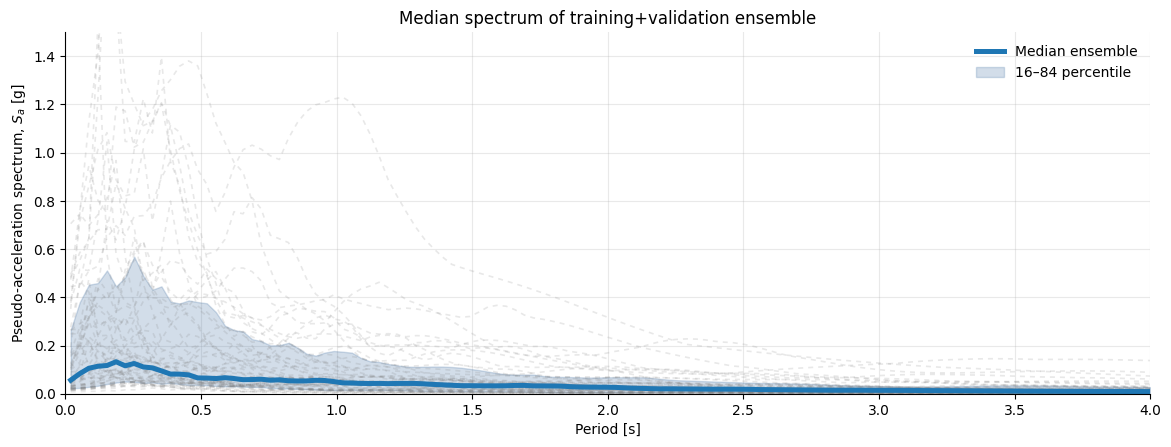

✅ Figura de espectros guardada en: /content/memoria/runs_colab/runs_results_models/B4_TEACHER_SPECTRA.png


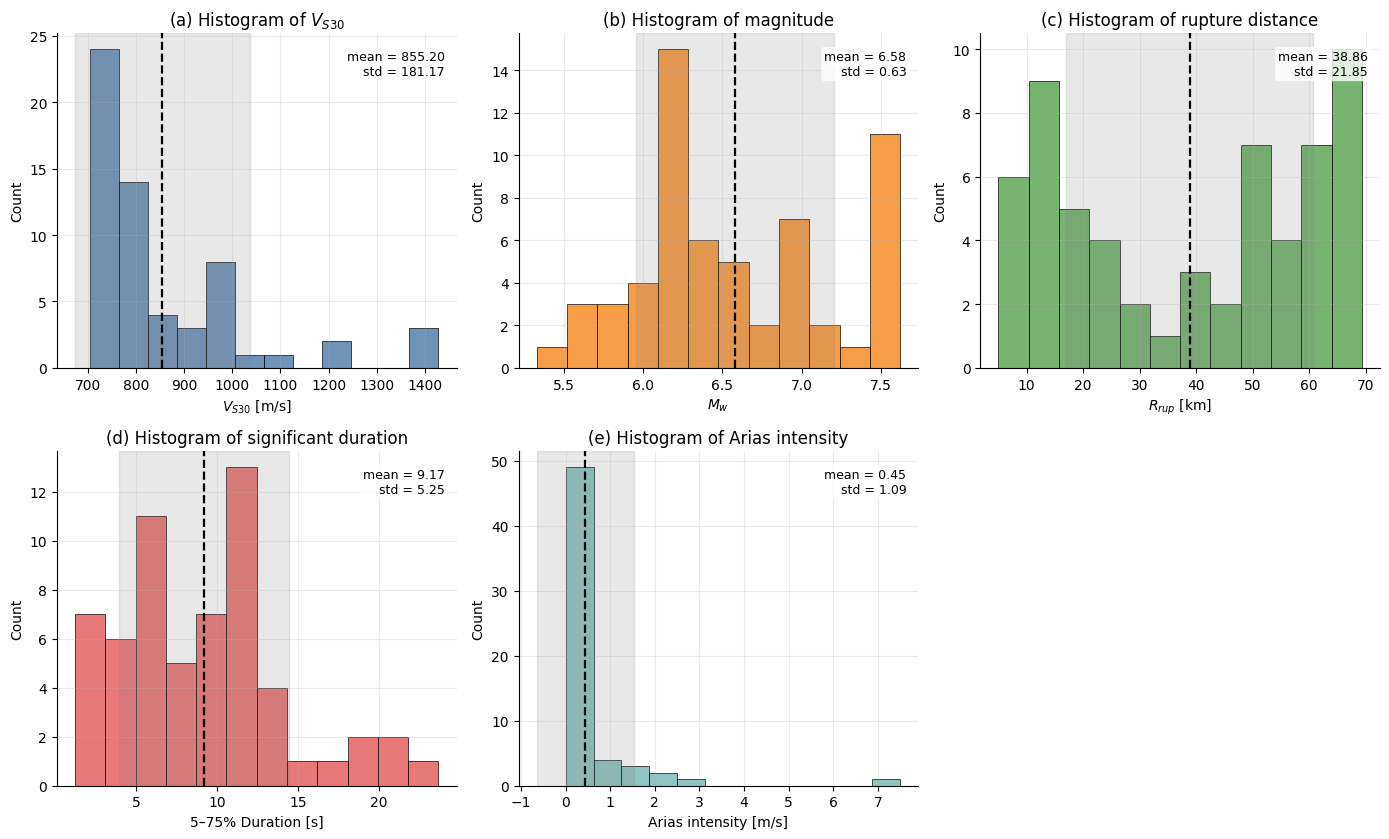

✅ Figura de histogramas guardada en: /content/memoria/runs_colab/runs_results_models/B4_TEACHER_DATASET_HISTOGRAMS.png
✅ Metadata filtrada guardada en: /content/memoria/runs_colab/runs_results_models/B4_TEACHER_DATASET_METADATA_FILTERED.csv


In [ ]:
# ============================================
# BLOQUE 4 — CELDA 22
# Caracterización del dataset Teacher:
# FIGURA 1: espectro mediano del conjunto TRAIN+VAL
# FIGURA 2: histogramas de metadata de registros
# Inspirado en Fig. 9 del paper guía
# Fuente metadata:
#   /content/memoria/Time Series Records_MACRO.xlsm
#   Hoja: SearchResults
#   Header: fila 34
#   Datos: filas 35:120
#   Columnas: A:V
# ============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# CONFIG
# --------------------------------------------------
METADATA_PATH = "/content/memoria/runs_colab/Time Series Records_MACRO.xlsm"
METADATA_SHEET = "SearchResults"
HEADER_ROW = 34
DATA_END_ROW = 120
USECOLS = "A:V"

G_CONST = 9.80665

# Colores histogramas
COLOR_VS30   = "#4C78A8"
COLOR_MW     = "#F58518"
COLOR_RRUP   = "#54A24B"
COLOR_DUR    = "#E45756"
COLOR_ARIAS  = "#72B7B2"

# --------------------------------------------------
# Conjunto TRAIN + VAL del Teacher
# --------------------------------------------------
ENSEMBLE_IDS_T = sorted(TRAIN_IDS_CMP + VAL_IDS_CMP)
ensemble_files_t = [
    p for p in ALL_FILES
    if record_id_from_path(p) in ENSEMBLE_IDS_T
]

print("✅ Ensemble Teacher (TRAIN+VAL):", len(ensemble_files_t), "eventos")

# --------------------------------------------------
# Helper: espectro elástico SDOF
# --------------------------------------------------
def elastic_response_spectrum(acc_g, dt, periods, zeta=0.05):
    acc_g = np.asarray(acc_g, dtype=np.float64).reshape(-1)
    n = acc_g.size

    Sd = np.zeros_like(periods, dtype=np.float64)
    Sv = np.zeros_like(periods, dtype=np.float64)
    Sa = np.zeros_like(periods, dtype=np.float64)

    gamma = 0.5
    beta = 0.25

    for ip, T in enumerate(periods):
        if T <= 0:
            continue

        w = 2.0 * np.pi / T
        k = w**2
        c = 2.0 * zeta * w
        m = 1.0

        a0 = m/(beta*dt**2) + gamma*c/(beta*dt)
        a1 = m/(beta*dt) + (gamma/beta - 1.0)*c
        a2 = m*(1.0/(2.0*beta) - 1.0) + c*dt*(gamma/(2.0*beta) - 1.0)
        k_eff = k + a0

        u = 0.0
        v = 0.0
        a_rel = -acc_g[0]

        u_hist = np.zeros(n, dtype=np.float64)
        v_hist = np.zeros(n, dtype=np.float64)
        a_hist = np.zeros(n, dtype=np.float64)

        u_hist[0] = u
        v_hist[0] = v
        a_hist[0] = a_rel

        for i in range(1, n):
            p_eff = (-m * acc_g[i] + a0*u + a1*v + a2*a_rel)

            u_new = p_eff / k_eff
            v_new = gamma/(beta*dt)*(u_new - u) + (1.0 - gamma/beta)*v + dt*(1.0 - gamma/(2.0*beta))*a_rel
            a_new = (u_new - u)/(beta*dt**2) - v/(beta*dt) - (1.0/(2.0*beta) - 1.0)*a_rel

            u, v, a_rel = u_new, v_new, a_new
            u_hist[i] = u
            v_hist[i] = v
            a_hist[i] = a_rel

        sd = np.max(np.abs(u_hist))
        sv = np.max(np.abs(v_hist))
        sa = np.max(np.abs(a_hist + acc_g))

        Sd[ip] = sd
        Sv[ip] = sv
        Sa[ip] = sa

    return Sa, Sv, Sd

# --------------------------------------------------
# Helpers limpieza
# --------------------------------------------------
def clean_numeric_series(s):
    return pd.to_numeric(
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.replace('"', "", regex=False)
         .str.strip(),
        errors="coerce"
    )

def clean_text_series(s):
    return (
        s.astype(str)
         .str.replace('"', "", regex=False)
         .str.strip()
    )

# --------------------------------------------------
# Leer metadata desde XLSM
# --------------------------------------------------
df_meta = pd.read_excel(
    METADATA_PATH,
    sheet_name=METADATA_SHEET,
    header=HEADER_ROW - 1,
    usecols=USECOLS,
    nrows=(DATA_END_ROW - HEADER_ROW)
)

df_meta.columns = [str(c).strip() for c in df_meta.columns]

print("✅ Metadata cargada:", df_meta.shape)
print("✅ Columnas detectadas:")
print(list(df_meta.columns))

# --------------------------------------------------
# Columnas esperadas
# --------------------------------------------------
col_result_id = "Result ID"
col_mw        = "Magnitude"
col_vs30      = "Vs30 (m/sec)"
col_rrup      = "Rrup (km)"
col_dur_575   = "5-75% Duration (sec)"
col_arias     = "Arias Intensity (m/sec)"
col_eq_name   = "Earthquake Name"
col_station   = "Station Name"
col_year      = "Year"

needed_cols = [
    col_result_id, col_mw, col_vs30, col_rrup,
    col_dur_575, col_arias, col_eq_name, col_station, col_year
]
missing_cols = [c for c in needed_cols if c not in df_meta.columns]
assert len(missing_cols) == 0, f"Faltan columnas en metadata: {missing_cols}"

# --------------------------------------------------
# Limpiar columnas
# --------------------------------------------------
df_meta[col_result_id] = clean_numeric_series(df_meta[col_result_id]).astype("Int64")
df_meta[col_mw]        = clean_numeric_series(df_meta[col_mw])
df_meta[col_vs30]      = clean_numeric_series(df_meta[col_vs30])
df_meta[col_rrup]      = clean_numeric_series(df_meta[col_rrup])
df_meta[col_dur_575]   = clean_numeric_series(df_meta[col_dur_575])
df_meta[col_arias]     = clean_numeric_series(df_meta[col_arias])
df_meta[col_year]      = clean_numeric_series(df_meta[col_year]).astype("Int64")

df_meta[col_eq_name] = clean_text_series(df_meta[col_eq_name])
df_meta[col_station] = clean_text_series(df_meta[col_station])

# --------------------------------------------------
# Mapear Result ID -> EQxxx
# --------------------------------------------------
df_meta["event"] = df_meta[col_result_id].apply(
    lambda x: f"EQ{int(x):03d}" if pd.notna(x) else None
)

df_meta_sel = df_meta[df_meta["event"].isin(ENSEMBLE_IDS_T)].copy()
df_meta_sel["event_num"] = df_meta_sel["event"].str.extract(r"EQ(\d+)").astype(float)
df_meta_sel = df_meta_sel.sort_values("event_num").drop(columns=["event_num"]).reset_index(drop=True)

print("✅ Metadata filtrada para TRAIN+VAL:", df_meta_sel.shape)
display(
    df_meta_sel[
        ["event", col_eq_name, col_year, col_station, col_mw, col_vs30, col_rrup, col_dur_575, col_arias]
    ].head(10)
)

# --------------------------------------------------
# Curvas espectrales del conjunto TRAIN+VAL
# --------------------------------------------------
PERIODS = np.linspace(0.02, 4.0, 120)
SA_ALL = []

for p in ensemble_files_t:
    rid, X, Y, dt = load_event_npz(p)
    ag = np.asarray(X[:, 1], dtype=np.float64)

    sa, sv, sd = elastic_response_spectrum(
        ag,
        dt=float(dt),
        periods=PERIODS,
        zeta=0.05
    )

    sa_g = sa / G_CONST
    SA_ALL.append(sa_g)

SA_ALL = np.asarray(SA_ALL, dtype=np.float64)

SA_MED = np.median(SA_ALL, axis=0)
SA_P16 = np.percentile(SA_ALL, 16, axis=0)
SA_P84 = np.percentile(SA_ALL, 84, axis=0)

print("✅ Espectros calculados:", SA_ALL.shape)

# --------------------------------------------------
# Helper histogramas con mean y std (sin leyenda)
# --------------------------------------------------
def add_hist_with_stats(ax, data, color, title, xlabel, bins=12):
    x = pd.Series(data).dropna().values
    if len(x) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Count")
        return

    mu = np.mean(x)
    sd = np.std(x, ddof=0)

    ax.hist(x, bins=bins, color=color, alpha=0.80, edgecolor="black", linewidth=0.6)
    ax.axvline(mu, color="black", linestyle="--", linewidth=1.6)
    ax.axvspan(mu - sd, mu + sd, color="gray", alpha=0.18)

    txt = f"mean = {mu:.2f}\nstd = {sd:.2f}"
    ax.text(
        0.97, 0.95, txt,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="none")
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# --------------------------------------------------
# FIGURA 1: ESPECTROS
# --------------------------------------------------
FIG_PATH_SPECTRA = os.path.join(RUNS_DIR_RESULTS, "B4_TEACHER_SPECTRA.png")

fig1, ax1 = plt.subplots(figsize=(14, 5.2))

# ancho:alto = 3:1
ax1.set_box_aspect(1/3)

for i in range(SA_ALL.shape[0]):
    ax1.plot(
        PERIODS,
        SA_ALL[i],
        color="gray",
        alpha=0.18,              # más visible pero sin saturar
        linewidth=1.2,           # más grueso
        linestyle=(0, (3, 3))    # línea segmentada elegante (tipo paper)
    )

# línea mediana más gruesa
ax1.plot(PERIODS, SA_MED, linewidth=3.6, label="Median ensemble")
ax1.fill_between(PERIODS, SA_P16, SA_P84, alpha=0.25, color="#4C78A8",label="16–84 percentile")

ax1.set_xlim(0.0, 4.0)
ax1.set_ylim(0.0, 1.5)
ax1.set_xlabel("Period [s]")
ax1.set_ylabel("Pseudo-acceleration spectrum, $S_a$ [g]")
ax1.set_title("Median spectrum of training+validation ensemble")
ax1.set_axisbelow(True)
ax1.grid(True, alpha=0.28)
ax1.legend(frameon=False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

plt.savefig(FIG_PATH_SPECTRA, dpi=220, bbox_inches="tight")
plt.show()

print("✅ Figura de espectros guardada en:", FIG_PATH_SPECTRA)

# --------------------------------------------------
# FIGURA 2: HISTOGRAMAS
# --------------------------------------------------
FIG_PATH_HISTS = os.path.join(RUNS_DIR_RESULTS, "B4_TEACHER_DATASET_HISTOGRAMS.png")

fig2, axs = plt.subplots(2, 3, figsize=(14, 8.5))
axs = axs.ravel()

add_hist_with_stats(
    axs[0],
    df_meta_sel[col_vs30].values,
    COLOR_VS30,
    "(a) Histogram of $V_{S30}$",
    "$V_{S30}$ [m/s]"
)

add_hist_with_stats(
    axs[1],
    df_meta_sel[col_mw].values,
    COLOR_MW,
    "(b) Histogram of magnitude",
    "$M_w$"
)

add_hist_with_stats(
    axs[2],
    df_meta_sel[col_rrup].values,
    COLOR_RRUP,
    "(c) Histogram of rupture distance",
    "$R_{rup}$ [km]"
)

add_hist_with_stats(
    axs[3],
    df_meta_sel[col_dur_575].values,
    COLOR_DUR,
    "(d) Histogram of significant duration",
    "5–75% Duration [s]"
)

add_hist_with_stats(
    axs[4],
    df_meta_sel[col_arias].values,
    COLOR_ARIAS,
    "(e) Histogram of Arias intensity",
    "Arias intensity [m/s]"
)

# panel vacío para balance visual
axs[5].axis("off")

plt.tight_layout()
plt.savefig(FIG_PATH_HISTS, dpi=220, bbox_inches="tight")
plt.show()

print("✅ Figura de histogramas guardada en:", FIG_PATH_HISTS)

# --------------------------------------------------
# Export opcional de metadata filtrada
# --------------------------------------------------
CSV_META_SEL = os.path.join(RUNS_DIR_RESULTS, "B4_TEACHER_DATASET_METADATA_FILTERED.csv")
df_meta_sel.to_csv(CSV_META_SEL, index=False)
print("✅ Metadata filtrada guardada en:", CSV_META_SEL)

In [ ]:
# ============================================
# BLOQUE 4 — CELDA 23
# Estadísticas del dataset TRAIN+VAL
# Inspirado en caracterización de datasets
# en papers de ingeniería sísmica
# ============================================

import pandas as pd
import os

# --------------------------------------------------
# Variables de metadata a analizar
# --------------------------------------------------
META_COLUMNS = {
    "Mw": "Magnitude",
    "Vs30": "Vs30 (m/sec)",
    "Rrup": "Rrup (km)",
    "Duration_5_75": "5-75% Duration (sec)",
    "Arias_Intensity": "Arias Intensity (m/sec)"
}

# --------------------------------------------------
# Construir tabla de estadísticas
# --------------------------------------------------
stats_rows = []

for label, col in META_COLUMNS.items():

    values = df_meta_sel[col].dropna().values

    stats_rows.append({
        "Variable": label,
        "Mean": values.mean(),
        "Median": pd.Series(values).median(),
        "Std": values.std(),
        "Min": values.min(),
        "Max": values.max(),
        "N": len(values)
    })

df_dataset_stats = pd.DataFrame(stats_rows)

# ordenar columnas
df_dataset_stats = df_dataset_stats[
    ["Variable", "Mean", "Median", "Std", "Min", "Max", "N"]
]

print("📊 Estadísticas del dataset TRAIN+VAL (Teacher)")
display(df_dataset_stats)

# --------------------------------------------------
# Guardar tabla para el informe
# --------------------------------------------------
CSV_STATS_PATH = os.path.join(
    RUNS_DIR_RESULTS,
    "B4_TEACHER_DATASET_STATISTICS.csv"
)

df_dataset_stats.to_csv(CSV_STATS_PATH, index=False)

print("✅ Tabla guardada en:", CSV_STATS_PATH)

📊 Estadísticas del dataset TRAIN+VAL (Teacher)


,Variable,Mean,Median,Std,Min,Max,N
0,Mw,6.578833,6.30,0.625742,5.33,7.62,60
1,Vs30,855.202667,789.18,181.172520,704.64,1428.14,60
2,Rrup,38.856667,42.42,21.848138,5.02,69.31,60
3,Duration_5_75,9.168333,9.00,5.251682,1.20,23.70,60
4,Arias_Intensity,0.445000,0.10,1.093225,0.00,7.50,60


✅ Tabla guardada en: /content/memoria/runs_colab/runs_results_models/B4_TEACHER_DATASET_STATISTICS.csv


✅ Teacher history: leído -> /content/memoria/runs_colab/runs_notebook_B_teacher/TEACHER_FINAL_WINDOWS_OFFICIAL_history.csv
✅ Student_AF history: leído -> /content/memoria/runs_colab/runs_notebook_A_student/STUDENT_AF_GKF5_V2_SR_history_mean.csv
✅ Student_Mz history: leído -> /content/memoria/runs_colab/runs_notebook_A_student/STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE_history.csv
⚠️ Teacher scatter: no existe -> /content/memoria/runs_colab/runs_results_models/TEACHER_SCATTER_DATA.csv
⚠️ Student_AF scatter: no existe -> /content/memoria/runs_colab/runs_results_models/STUDENT_AF_SCATTER_DATA.csv
⚠️ Student_Mz scatter: no existe -> /content/memoria/runs_colab/runs_results_models/STUDENT_MZ_SCATTER_DATA.csv


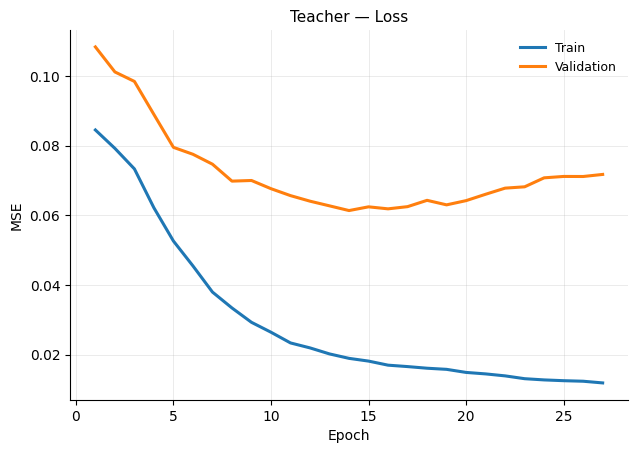

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_TEACHER_LOSS.png


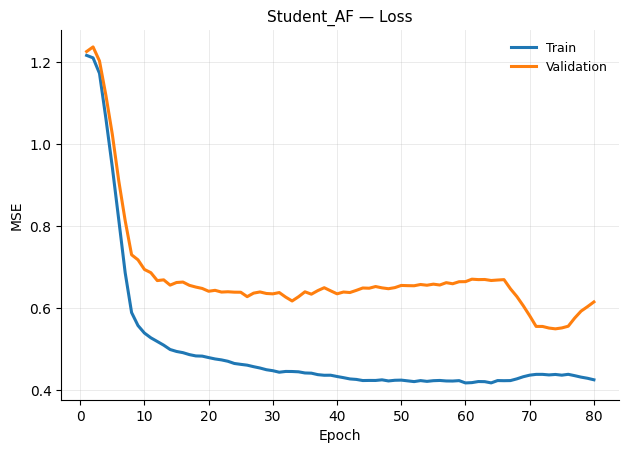

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_STUDENT_AF_LOSS.png


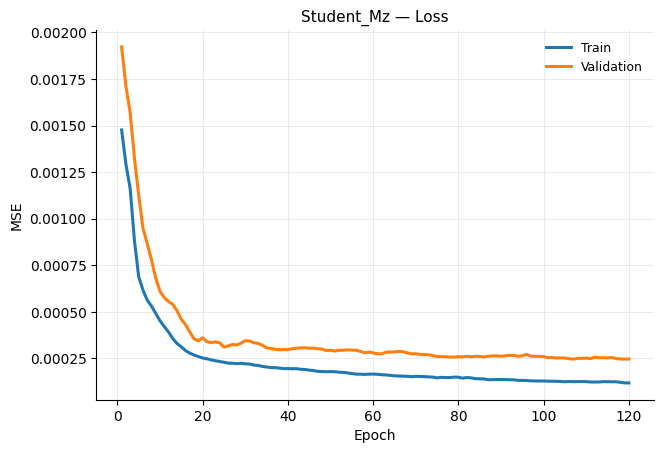

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_STUDENT_MZ_LOSS.png


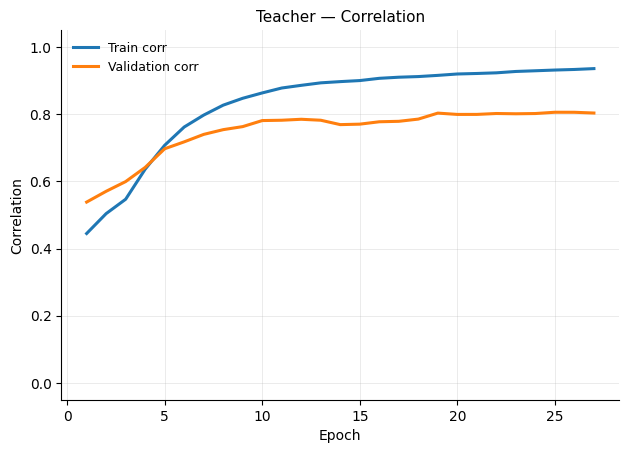

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_TEACHER_CORR.png


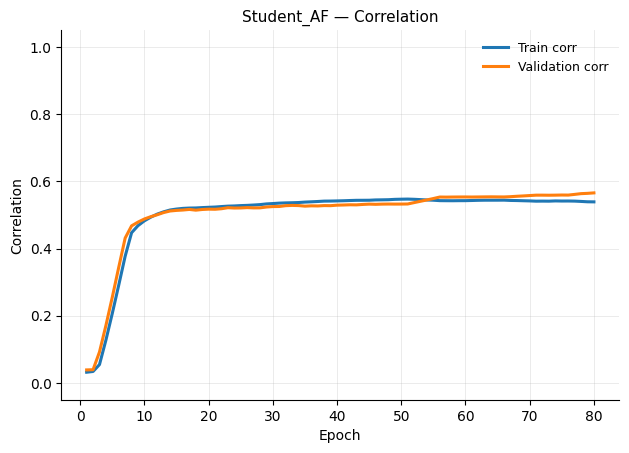

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_STUDENT_AF_CORR.png


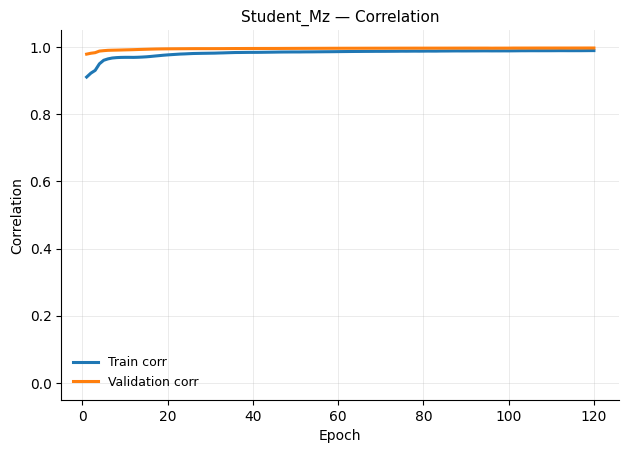

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_STUDENT_MZ_CORR.png


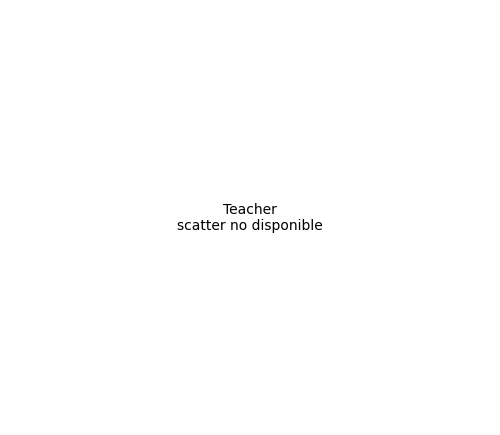

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_TEACHER_SCATTER.png


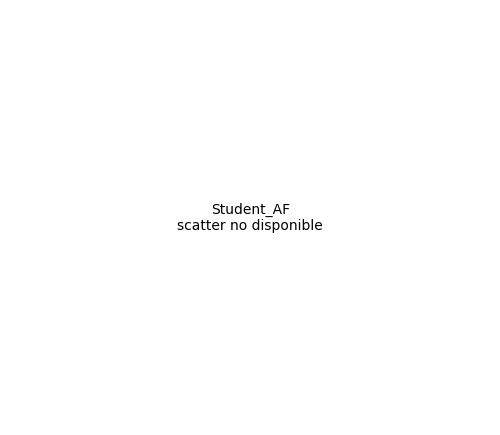

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_STUDENT_AF_SCATTER.png


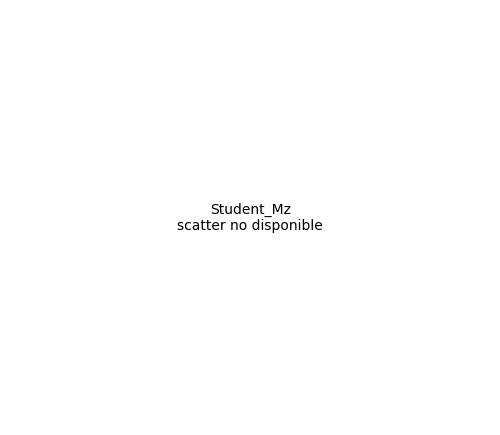

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_STUDENT_MZ_SCATTER.png


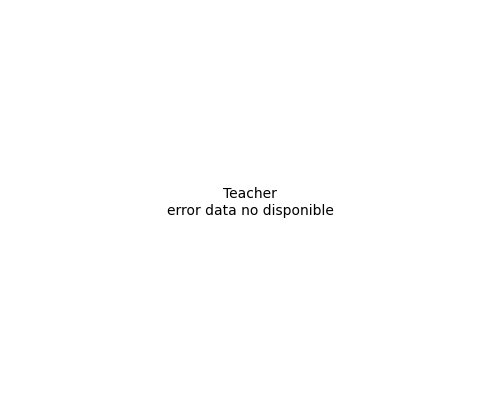

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_TEACHER_ERROR_HIST.png


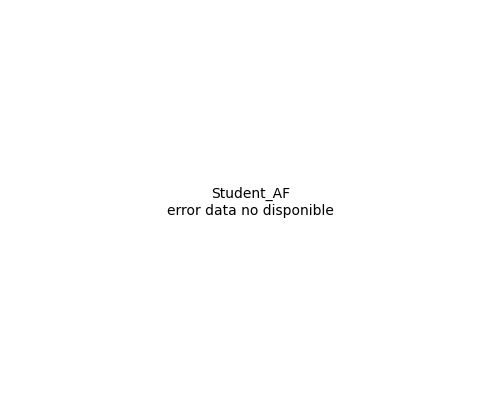

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_STUDENT_AF_ERROR_HIST.png


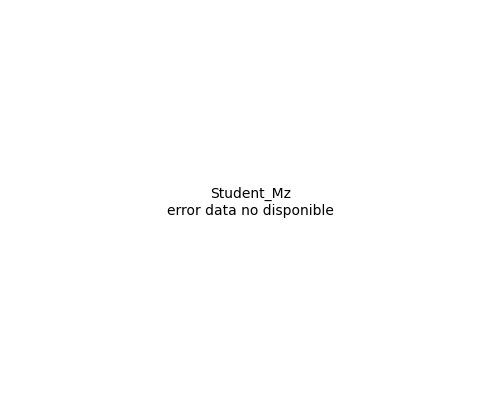

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_STUDENT_MZ_ERROR_HIST.png


In [ ]:
# ============================================
# BLOQUE 4 — CELDA 24 CORREGIDA
# Figuras separadas para entrenamiento/validación
# - Loss curves (una figura por red)
# - Corr curves (una figura por red)
# - Scatter (una figura por red, si existe data)
# - Error histogram (una figura por red, si existe data)
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Rutas esperadas
# --------------------------------------------------
TEACHER_HIST_CSV = os.path.join(
    ROOT, "runs_colab", "runs_notebook_B_teacher",
    "TEACHER_FINAL_WINDOWS_OFFICIAL_history.csv"
)

STUDENT_AF_HIST_CSV = os.path.join(
    ROOT, "runs_colab", "runs_notebook_A_student",
    "STUDENT_AF_GKF5_V2_SR_history_mean.csv"
)

STUDENT_MZ_HIST_CSV = os.path.join(
    ROOT, "runs_colab", "runs_notebook_A_student",
    "STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE_history.csv"
)

# Opcionales
TEACHER_PRED_CSV = os.path.join(RUNS_DIR_RESULTS, "TEACHER_SCATTER_DATA.csv")
STUDENT_AF_PRED_CSV = os.path.join(RUNS_DIR_RESULTS, "STUDENT_AF_SCATTER_DATA.csv")
STUDENT_MZ_PRED_CSV = os.path.join(RUNS_DIR_RESULTS, "STUDENT_MZ_SCATTER_DATA.csv")

# --------------------------------------------------
# Helper lectura segura
# --------------------------------------------------
def safe_read_csv(path, tag):
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"✅ {tag}: leído -> {path}")
        return df
    else:
        print(f"⚠️ {tag}: no existe -> {path}")
        return None

def smooth_curve(y, win=5):
    y = np.asarray(y, dtype=float)
    if len(y) <= 2:
        return y.copy()
    win = int(min(win, len(y)))
    if win < 2:
        return y.copy()
    if win % 2 == 0:
        win = max(1, win - 1)
    return pd.Series(y).rolling(window=win, center=True, min_periods=1).mean().values

def infer_epoch_col(df):
    for c in ["epoch", "Epoch", "ep"]:
        if c in df.columns:
            return c
    return None

def infer_loss_cols(df):
    train_candidates = ["train_loss", "loss_train", "tr_loss", "train", "TrainLoss"]
    val_candidates = ["val_loss", "valid_loss", "validation_loss", "loss_val", "va_loss", "val", "ValLoss"]
    train_col = next((c for c in train_candidates if c in df.columns), None)
    val_col   = next((c for c in val_candidates if c in df.columns), None)
    return train_col, val_col

def infer_corr_cols(df):
    train_candidates = ["train_corr", "tr_corr", "corr_train", "train_correlation"]
    val_candidates = ["val_corr", "valid_corr", "validation_corr", "va_corr", "corr_val", "val_correlation"]
    train_col = next((c for c in train_candidates if c in df.columns), None)
    val_col   = next((c for c in val_candidates if c in df.columns), None)
    return train_col, val_col

# --------------------------------------------------
# Helpers de plots
# --------------------------------------------------
def plot_loss_single(df, name, save_path):
    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    if df is None:
        ax.text(0.5, 0.5, f"{name}\nhistory no disponible", ha="center", va="center")
        ax.axis("off")
    else:
        ep_col = infer_epoch_col(df)
        tr_col, va_col = infer_loss_cols(df)

        if ep_col is None or (tr_col is None and va_col is None):
            ax.text(0.5, 0.5, f"{name}\ncolumnas de loss no encontradas", ha="center", va="center")
            ax.axis("off")
        else:
            x = df[ep_col].values

            if tr_col is not None:
                ax.plot(x, smooth_curve(df[tr_col].values, win=5), linewidth=2.2, label="Train")
            if va_col is not None:
                ax.plot(x, smooth_curve(df[va_col].values, win=5), linewidth=2.2, label="Validation")

            ax.set_title(f"{name} — Loss", fontsize=11)
            ax.set_xlabel("Epoch")
            ax.set_ylabel("MSE")
            ax.grid(True, alpha=0.25, linewidth=0.7)
            ax.legend(frameon=False, fontsize=9)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    fig.savefig(save_path, dpi=260, bbox_inches="tight")
    plt.show()
    print("✅ Guardado:", save_path)

def plot_corr_single(df, name, save_path):
    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    if df is None:
        ax.text(0.5, 0.5, f"{name}\nhistory no disponible", ha="center", va="center")
        ax.axis("off")
    else:
        ep_col = infer_epoch_col(df)
        tr_col, va_col = infer_corr_cols(df)

        if ep_col is None or (tr_col is None and va_col is None):
            ax.text(0.5, 0.5, f"{name}\ncolumnas de corr no encontradas", ha="center", va="center")
            ax.axis("off")
        else:
            x = df[ep_col].values

            if tr_col is not None:
                ax.plot(x, smooth_curve(df[tr_col].values, win=5), linewidth=2.2, label="Train corr")
            if va_col is not None:
                ax.plot(x, smooth_curve(df[va_col].values, win=5), linewidth=2.2, label="Validation corr")

            ax.set_title(f"{name} — Correlation", fontsize=11)
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Correlation")
            ax.set_ylim(-0.05, 1.05)
            ax.grid(True, alpha=0.25, linewidth=0.7)
            ax.legend(frameon=False, fontsize=9)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    fig.savefig(save_path, dpi=260, bbox_inches="tight")
    plt.show()
    print("✅ Guardado:", save_path)

def plot_scatter_single(df, name, save_path):
    fig, ax = plt.subplots(figsize=(6.2, 5.4))

    if df is None or not {"y_true", "y_pred"}.issubset(df.columns):
        ax.text(0.5, 0.5, f"{name}\nscatter no disponible", ha="center", va="center")
        ax.axis("off")
    else:
        yt = df["y_true"].values
        yp = df["y_pred"].values

        ax.scatter(yt, yp, s=8, alpha=0.35)
        lo = min(np.min(yt), np.min(yp))
        hi = max(np.max(yt), np.max(yp))
        ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5)

        ax.set_title(f"{name} — Scatter", fontsize=11)
        ax.set_xlabel("True")
        ax.set_ylabel("Predicted")
        ax.grid(True, alpha=0.25, linewidth=0.7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.savefig(save_path, dpi=260, bbox_inches="tight")
    plt.show()
    print("✅ Guardado:", save_path)

def plot_error_hist_single(df, name, save_path):
    fig, ax = plt.subplots(figsize=(6.2, 5.0))

    if df is None:
        ax.text(0.5, 0.5, f"{name}\nerror data no disponible", ha="center", va="center")
        ax.axis("off")
    else:
        if "error" in df.columns:
            err = df["error"].values
        elif {"y_true", "y_pred"}.issubset(df.columns):
            err = df["y_pred"].values - df["y_true"].values
        else:
            ax.text(0.5, 0.5, f"{name}\nerror data no disponible", ha="center", va="center")
            ax.axis("off")
            fig.savefig(save_path, dpi=260, bbox_inches="tight")
            plt.show()
            print("✅ Guardado:", save_path)
            return

        ax.hist(err, bins=30, alpha=0.8)
        ax.axvline(0.0, linestyle="--", linewidth=1.5)
        ax.set_title(f"{name} — Error histogram", fontsize=11)
        ax.set_xlabel("Prediction error")
        ax.set_ylabel("Count")
        ax.grid(True, alpha=0.25, linewidth=0.7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.savefig(save_path, dpi=260, bbox_inches="tight")
    plt.show()
    print("✅ Guardado:", save_path)

# --------------------------------------------------
# Leer histories
# --------------------------------------------------
df_teacher_hist    = safe_read_csv(TEACHER_HIST_CSV, "Teacher history")
df_student_af_hist = safe_read_csv(STUDENT_AF_HIST_CSV, "Student_AF history")
df_student_mz_hist = safe_read_csv(STUDENT_MZ_HIST_CSV, "Student_Mz history")

# --------------------------------------------------
# Leer scatter opcionales
# --------------------------------------------------
df_teacher_pred    = safe_read_csv(TEACHER_PRED_CSV, "Teacher scatter")
df_student_af_pred = safe_read_csv(STUDENT_AF_PRED_CSV, "Student_AF scatter")
df_student_mz_pred = safe_read_csv(STUDENT_MZ_PRED_CSV, "Student_Mz scatter")

# --------------------------------------------------
# Loss figures separadas
# --------------------------------------------------
FIG_PATH_TEACHER_LOSS = os.path.join(RUNS_DIR_RESULTS, "B4_TEACHER_LOSS.png")
FIG_PATH_STUDENT_AF_LOSS = os.path.join(RUNS_DIR_RESULTS, "B4_STUDENT_AF_LOSS.png")
FIG_PATH_STUDENT_MZ_LOSS = os.path.join(RUNS_DIR_RESULTS, "B4_STUDENT_MZ_LOSS.png")

plot_loss_single(df_teacher_hist, "Teacher", FIG_PATH_TEACHER_LOSS)
plot_loss_single(df_student_af_hist, "Student_AF", FIG_PATH_STUDENT_AF_LOSS)
plot_loss_single(df_student_mz_hist, "Student_Mz", FIG_PATH_STUDENT_MZ_LOSS)

# --------------------------------------------------
# Corr figures separadas
# --------------------------------------------------
FIG_PATH_TEACHER_CORR = os.path.join(RUNS_DIR_RESULTS, "B4_TEACHER_CORR.png")
FIG_PATH_STUDENT_AF_CORR = os.path.join(RUNS_DIR_RESULTS, "B4_STUDENT_AF_CORR.png")
FIG_PATH_STUDENT_MZ_CORR = os.path.join(RUNS_DIR_RESULTS, "B4_STUDENT_MZ_CORR.png")

plot_corr_single(df_teacher_hist, "Teacher", FIG_PATH_TEACHER_CORR)
plot_corr_single(df_student_af_hist, "Student_AF", FIG_PATH_STUDENT_AF_CORR)
plot_corr_single(df_student_mz_hist, "Student_Mz", FIG_PATH_STUDENT_MZ_CORR)

# --------------------------------------------------
# Scatter figures separadas (opcionales)
# --------------------------------------------------
FIG_PATH_TEACHER_SCATTER = os.path.join(RUNS_DIR_RESULTS, "B4_TEACHER_SCATTER.png")
FIG_PATH_STUDENT_AF_SCATTER = os.path.join(RUNS_DIR_RESULTS, "B4_STUDENT_AF_SCATTER.png")
FIG_PATH_STUDENT_MZ_SCATTER = os.path.join(RUNS_DIR_RESULTS, "B4_STUDENT_MZ_SCATTER.png")

plot_scatter_single(df_teacher_pred, "Teacher", FIG_PATH_TEACHER_SCATTER)
plot_scatter_single(df_student_af_pred, "Student_AF", FIG_PATH_STUDENT_AF_SCATTER)
plot_scatter_single(df_student_mz_pred, "Student_Mz", FIG_PATH_STUDENT_MZ_SCATTER)

# --------------------------------------------------
# Error histogram figures separadas (opcionales)
# --------------------------------------------------
FIG_PATH_TEACHER_ERRHIST = os.path.join(RUNS_DIR_RESULTS, "B4_TEACHER_ERROR_HIST.png")
FIG_PATH_STUDENT_AF_ERRHIST = os.path.join(RUNS_DIR_RESULTS, "B4_STUDENT_AF_ERROR_HIST.png")
FIG_PATH_STUDENT_MZ_ERRHIST = os.path.join(RUNS_DIR_RESULTS, "B4_STUDENT_MZ_ERROR_HIST.png")

plot_error_hist_single(df_teacher_pred, "Teacher", FIG_PATH_TEACHER_ERRHIST)
plot_error_hist_single(df_student_af_pred, "Student_AF", FIG_PATH_STUDENT_AF_ERRHIST)
plot_error_hist_single(df_student_mz_pred, "Student_Mz", FIG_PATH_STUDENT_MZ_ERRHIST)

Eventos excluidos: []
Teacher rows: (95235, 6)
Student rows: (95235, 6)


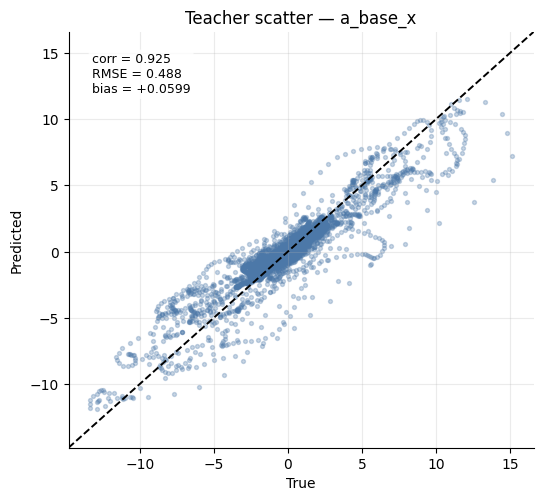

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_HOLDOUT_TEACHER_SCATTER_a_base_x.png


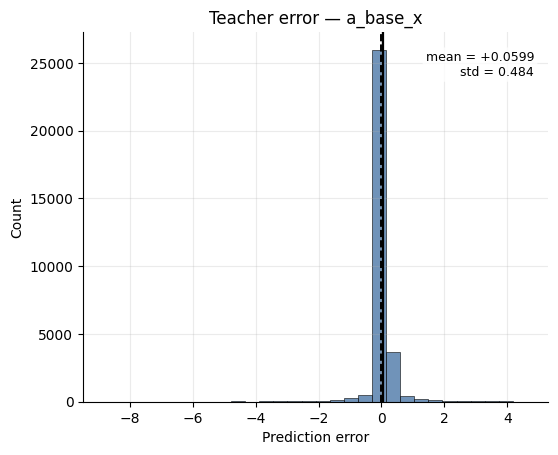

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_HOLDOUT_TEACHER_ERROR_HIST_a_base_x.png


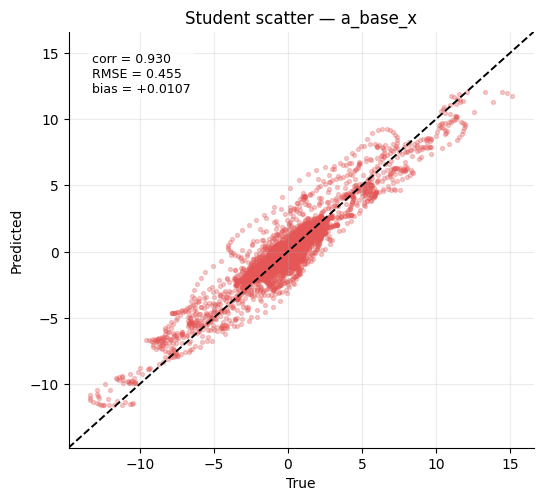

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_HOLDOUT_STUDENT_SCATTER_a_base_x.png


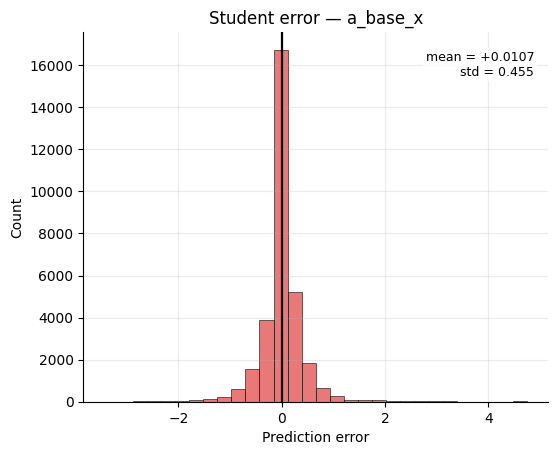

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_HOLDOUT_STUDENT_ERROR_HIST_a_base_x.png


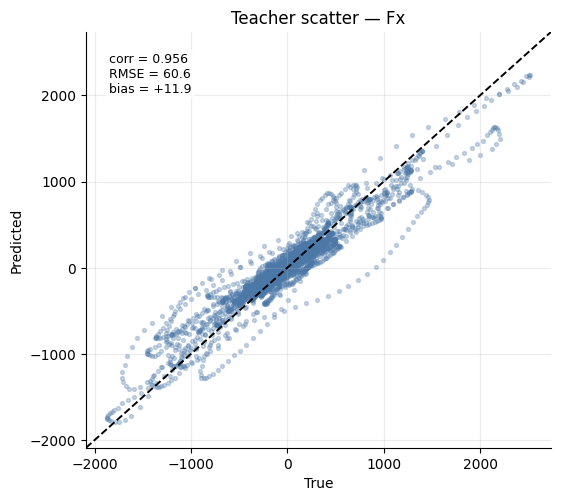

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_HOLDOUT_TEACHER_SCATTER_Fx.png


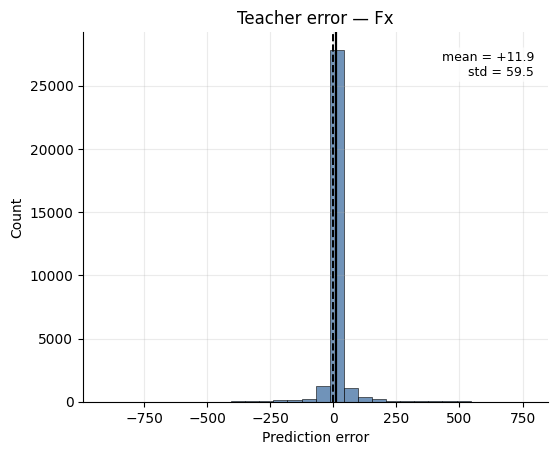

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_HOLDOUT_TEACHER_ERROR_HIST_Fx.png


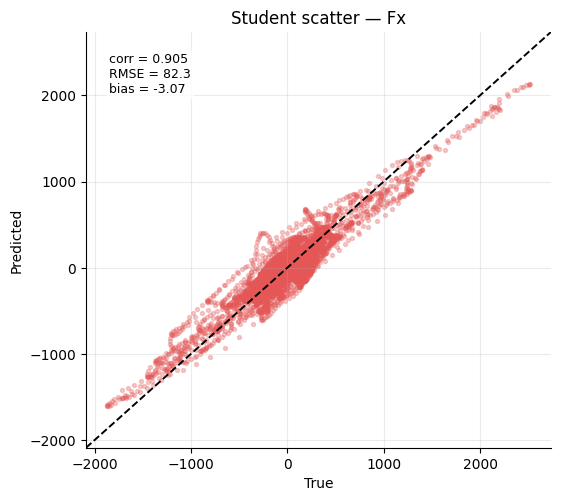

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_HOLDOUT_STUDENT_SCATTER_Fx.png


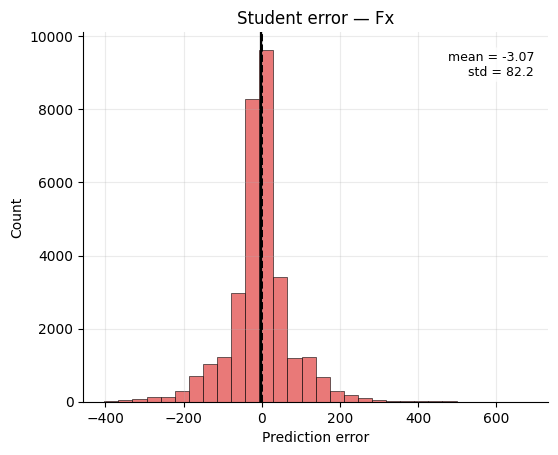

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_HOLDOUT_STUDENT_ERROR_HIST_Fx.png


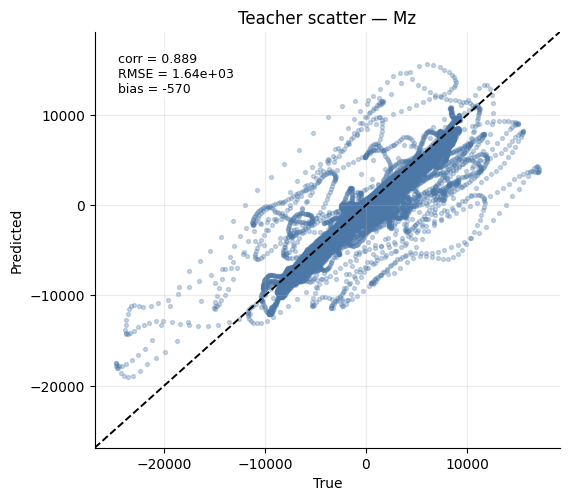

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_HOLDOUT_TEACHER_SCATTER_Mz.png


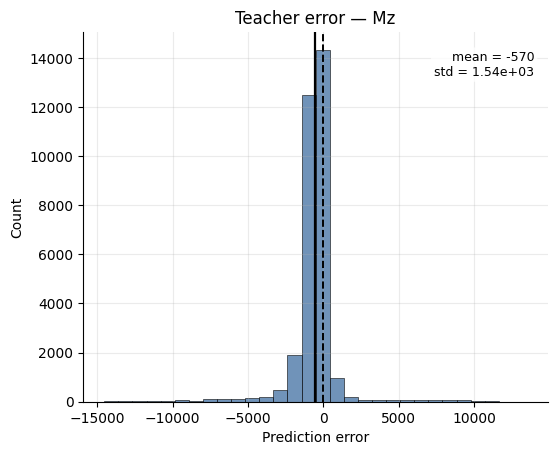

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_HOLDOUT_TEACHER_ERROR_HIST_Mz.png


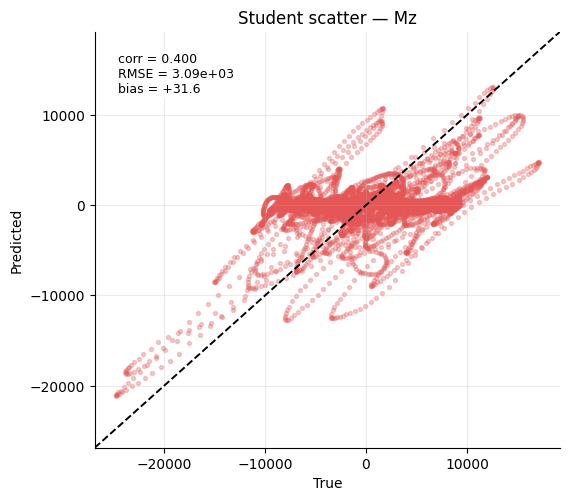

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_HOLDOUT_STUDENT_SCATTER_Mz.png


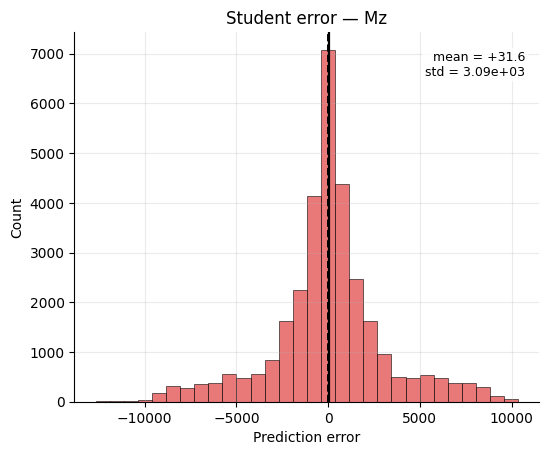

✅ Guardado: /content/memoria/runs_colab/runs_results_models/B4_HOLDOUT_STUDENT_ERROR_HIST_Mz.png
✅ Todas las figuras separadas de comparación final fueron generadas.


In [ ]:
# ============================================
# BLOQUE 4 — CELDA 25 CORREGIDA
# Scatter plots y error histograms separados
# Comparación final Teacher vs Student
# sobre los 4 eventos holdout
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Rutas de entrada
# --------------------------------------------------
CSV_COMPARE_TEACHER = os.path.join(
    RUNS_DIR_RESULTS,
    "COMPARE_HOLDOUT_TEACHER_SCATTER_DATA.csv"
)
CSV_COMPARE_STUDENT = os.path.join(
    RUNS_DIR_RESULTS,
    "COMPARE_HOLDOUT_STUDENT_SCATTER_DATA.csv"
)

assert os.path.exists(CSV_COMPARE_TEACHER), f"No existe: {CSV_COMPARE_TEACHER}"
assert os.path.exists(CSV_COMPARE_STUDENT), f"No existe: {CSV_COMPARE_STUDENT}"

df_teacher_scatter = pd.read_csv(CSV_COMPARE_TEACHER)
df_student_scatter = pd.read_csv(CSV_COMPARE_STUDENT)

# --------------------------------------------------
# Excluir eventos problemáticos
# --------------------------------------------------
EXCLUDE_EVENTS = []

df_teacher_scatter = df_teacher_scatter[
    ~df_teacher_scatter["event"].isin(EXCLUDE_EVENTS)
].copy()

df_student_scatter = df_student_scatter[
    ~df_student_scatter["event"].isin(EXCLUDE_EVENTS)
].copy()

print("Eventos excluidos:", EXCLUDE_EVENTS)
print("Teacher rows:", df_teacher_scatter.shape)
print("Student rows:", df_student_scatter.shape)

# --------------------------------------------------
# Config estética
# --------------------------------------------------
TARGETS = ["a_base_x", "Fx", "Mz"]

COLOR_TEACHER = "#4C78A8"
COLOR_STUDENT = "#E45756"

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def get_target_df(df, target):
    return df[df["target"] == target].copy()

def get_common_scatter_limits(df_t, df_s):
    vals = []
    for d in [df_t, df_s]:
        if d is not None and not d.empty:
            vals.extend(d["y_true"].values.tolist())
            vals.extend(d["y_pred"].values.tolist())

    if len(vals) == 0:
        return None, None

    lo = np.min(vals)
    hi = np.max(vals)

    if np.isclose(lo, hi):
        pad = 1.0
    else:
        pad = 0.05 * (hi - lo)

    return lo - pad, hi + pad

def plot_scatter_model(df, target, color, model_name, save_path, xlim=None, ylim=None):
    fig, ax = plt.subplots(figsize=(6.0, 5.4))

    d = get_target_df(df, target)

    if d.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
    else:
        yt = d["y_true"].values
        yp = d["y_pred"].values

        ax.scatter(yt, yp, s=8, alpha=0.30, color=color)

        if xlim is None or ylim is None:
            lo = min(np.min(yt), np.min(yp))
            hi = max(np.max(yt), np.max(yp))
            ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.4, color="black")
        else:
            ax.plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], linestyle="--", linewidth=1.4, color="black")
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)

        corr = np.corrcoef(yt, yp)[0, 1] if (np.std(yt) > 0 and np.std(yp) > 0) else np.nan
        rmse = np.sqrt(np.mean((yp - yt) ** 2))
        bias = np.mean(yp - yt)

        txt = f"corr = {corr:.3f}\nRMSE = {rmse:.3g}\nbias = {bias:+.3g}"
        ax.text(
            0.05, 0.95, txt,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="none")
        )

        ax.set_title(f"{model_name} scatter — {target}")
        ax.set_xlabel("True")
        ax.set_ylabel("Predicted")
        ax.grid(True, alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.savefig(save_path, dpi=240, bbox_inches="tight")
    plt.show()
    print("✅ Guardado:", save_path)

def plot_error_hist_model(df, target, color, model_name, save_path):
    fig, ax = plt.subplots(figsize=(6.0, 4.8))

    d = get_target_df(df, target)

    if d.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
    else:
        err = d["error"].values
        mu = np.mean(err)
        sd = np.std(err, ddof=0)

        ax.hist(err, bins=30, color=color, alpha=0.80, edgecolor="black", linewidth=0.5)
        ax.axvline(0.0, linestyle="--", linewidth=1.4, color="black")
        ax.axvline(mu, linestyle="-", linewidth=1.6, color="black")

        txt = f"mean = {mu:+.3g}\nstd = {sd:.3g}"
        ax.text(
            0.97, 0.95, txt,
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="none")
        )

        ax.set_title(f"{model_name} error — {target}")
        ax.set_xlabel("Prediction error")
        ax.set_ylabel("Count")
        ax.grid(True, alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.savefig(save_path, dpi=240, bbox_inches="tight")
    plt.show()
    print("✅ Guardado:", save_path)

# --------------------------------------------------
# Generar figuras separadas por target y modelo
# --------------------------------------------------
for target in TARGETS:
    dft = get_target_df(df_teacher_scatter, target)
    dfs = get_target_df(df_student_scatter, target)

    lo, hi = get_common_scatter_limits(dft, dfs)
    common_xlim = (lo, hi) if lo is not None else None
    common_ylim = (lo, hi) if hi is not None else None

    # Teacher scatter
    out_teacher_scatter = os.path.join(
        RUNS_DIR_RESULTS,
        f"B4_HOLDOUT_TEACHER_SCATTER_{target}.png"
    )
    plot_scatter_model(
        df_teacher_scatter, target, COLOR_TEACHER, "Teacher",
        out_teacher_scatter,
        xlim=common_xlim, ylim=common_ylim
    )

    # Teacher error
    out_teacher_err = os.path.join(
        RUNS_DIR_RESULTS,
        f"B4_HOLDOUT_TEACHER_ERROR_HIST_{target}.png"
    )
    plot_error_hist_model(
        df_teacher_scatter, target, COLOR_TEACHER, "Teacher",
        out_teacher_err
    )

    # Student scatter
    out_student_scatter = os.path.join(
        RUNS_DIR_RESULTS,
        f"B4_HOLDOUT_STUDENT_SCATTER_{target}.png"
    )
    plot_scatter_model(
        df_student_scatter, target, COLOR_STUDENT, "Student",
        out_student_scatter,
        xlim=common_xlim, ylim=common_ylim
    )

    # Student error
    out_student_err = os.path.join(
        RUNS_DIR_RESULTS,
        f"B4_HOLDOUT_STUDENT_ERROR_HIST_{target}.png"
    )
    plot_error_hist_model(
        df_student_scatter, target, COLOR_STUDENT, "Student",
        out_student_err
    )

print("✅ Todas las figuras separadas de comparación final fueron generadas.")

In [ ]:
# ============================================
# BLOQUE 4 — CELDA 26
# Consolidar figuras del Bloque 4 en PDF
# ============================================
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.backends.backend_pdf import PdfPages

PDF_BLOCK4 = os.path.join(RUNS_DIR_RESULTS, "B4_COMPLEMENTARY_FIGURES.pdf")

# --------------------------------------------------
# Lista robusta de figuras a incluir
# --------------------------------------------------
FIGS_BLOCK4 = []

for var_name in [
    "FIG_PATH_SPECTRA",   # espectros
    "FIG_PATH_HISTS",     # histogramas metadata
    "FIG_PATH_MAIN",      # loss + corr
    "FIG_PATH_AUX",       # scatter + error histogram
    "FIG_PATH_SCHEME",    # esquema/framework
]:
    if var_name in globals():
        FIGS_BLOCK4.append(globals()[var_name])

print("📄 Figuras detectadas para PDF:")
for f in FIGS_BLOCK4:
    print(" -", f)

# --------------------------------------------------
# Exportar PDF
# --------------------------------------------------
with PdfPages(PDF_BLOCK4) as pdf:
    for fig_path in FIGS_BLOCK4:
        if os.path.exists(fig_path):
            img = mpimg.imread(fig_path)

            fig = plt.figure(figsize=(12, 7))
            plt.imshow(img)
            plt.axis("off")
            plt.tight_layout()

            pdf.savefig(fig, dpi=220)
            plt.close(fig)
        else:
            print("⚠️ No existe, se omite:", fig_path)

print("✅ PDF guardado:", PDF_BLOCK4)

📄 Figuras detectadas para PDF:
✅ PDF guardado: /content/memoria/runs_colab/runs_results_models/B4_COMPLEMENTARY_FIGURES.pdf
